# 🎯 FINAL: Bleeding Prediction MLP Training - Complete Pipeline

## 📚 Table of Contents
1. [Data Loading & Exploration](#1)
2. [Understanding the Input Data](#2)
3. [Temporal Feature Engineering](#3)
4. [Label Generation Strategy](#4)
5. [Train/Val/Test Split](#5)
6. [Model Architecture](#6)
7. [Training Loop](#7)
8. [Evaluation & Metrics](#8)
9. [Visualizations](#9)
10. [Final Summary](#10)

---

## 🎯 Goal

**Train an MLP to predict if bleeding will occur in the next 5 frames**

### Input Features:
- **Instruments**: 6 binary features (grasper, bipolar, hook, scissors, clipper, irrigator)
- **Blood area**: 1 continuous feature (pixels)
- **Temporal window**: Last 6 frames (current + 5 previous)

### Output:
- **Binary prediction**: Will bleeding occur? (Yes=1, No=0)

### Prediction Horizon:
- **5 frames ahead**: If bleeding peak is at frame 500, we label frames 495-499 as positive

---

## 🧠 The Behind-the-Scenes Logic

### Why This Approach?

1. **Temporal Context**: Bleeding doesn't happen instantly. There are warning signs in the frames leading up to a bleed.

2. **Multi-Modal Input**: Combining instrument usage + blood area gives the model context:
   - Which instruments are being used?
   - Is blood area increasing?
   - What's the trend over time?

3. **Early Warning System**: By predicting 5 frames ahead (~5 seconds at 1 FPS), we give surgeons time to react.

### How It Works:

```
Timeline:
Frame 490: [grasper, hook] blood=1000px  ← t-5
Frame 491: [grasper, hook] blood=1200px  ← t-4
Frame 492: [grasper, hook] blood=1500px  ← t-3
Frame 493: [grasper, hook] blood=2000px  ← t-2  
Frame 494: [grasper, hook] blood=3000px  ← t-1
Frame 495: [grasper, hook] blood=5000px  ← t (current) → LABEL = 1 (bleeding in 5 frames)
...
Frame 500: [all tools]      blood=25000px ← PEAK (actual bleeding event)
```

The MLP sees:
- **Rising blood trend** (1000 → 5000)
- **Consistent instrument use** (grasper + hook)
- **Acceleration in blood area**

And predicts: "Bleeding will occur soon!"

In [1]:
# Cell 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import json
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.9.0+cu128
CUDA available: True
GPU: NVIDIA H100 80GB HBM3


In [2]:
# Cell 2: Configuration
class Config:
    """All hyperparameters and settings in one place"""
    
    # Paths
    ALIGNED_DIR = Path("cleaned_aligned_dataset/aligned_dataset")
    MANUAL_DECISIONS_CSV = Path("quality_check/reports/video_quality_metrics.csv")
    OUTPUT_DIR = Path("bleeding_prediction_model")
    
    # Temporal window settings
    WINDOW_SIZE = 6  # Use current frame + 5 previous frames
    PREDICTION_HORIZON = 5  # Predict bleeding 5 frames ahead
    
    # Feature dimensions
    NUM_INSTRUMENTS = 6  # grasper, bipolar, hook, scissors, clipper, irrigator
    NUM_BASIC_FEATURES = 7  # 6 instruments + 1 blood area
    
    # Model architecture
    HIDDEN_DIMS = [256, 128, 64, 32]
    DROPOUT_RATES = [0.4, 0.3, 0.2, 0.1]
    
    # Training settings
    BATCH_SIZE = 256
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-4
    NUM_EPOCHS = 100
    EARLY_STOPPING_PATIENCE = 15
    
    # Data split
    TEST_SIZE = 0.15
    VAL_SIZE = 0.15
    
    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create output directory
Config.OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print("Configuration:")
print(f"  Device: {Config.DEVICE}")
print(f"  Window size: {Config.WINDOW_SIZE} frames")
print(f"  Prediction horizon: {Config.PREDICTION_HORIZON} frames")
print(f"  Batch size: {Config.BATCH_SIZE}")
print(f"  Learning rate: {Config.LEARNING_RATE}")

Configuration:
  Device: cuda
  Window size: 6 frames
  Prediction horizon: 5 frames
  Batch size: 256
  Learning rate: 0.001


---
# 📊 SECTION 1: Data Loading & Filtering
---

In [3]:
# Cell 3: Load Manual Review Decisions
print("Loading manual review decisions...\n")

if Config.MANUAL_DECISIONS_CSV.exists():
    decisions_df = pd.read_csv(Config.MANUAL_DECISIONS_CSV)
    
    # Check if manual decisions are filled in
    if 'manual_decision' in decisions_df.columns:
        # Filter for KEEP videos
        keep_videos = decisions_df[
            decisions_df['manual_decision'].str.upper() == 'KEEP'
        ]['video_id'].tolist()
        
        if len(keep_videos) == 0:
            print("⚠️  No videos marked as KEEP in manual_decision column!")
            print("   Using auto recommendations instead...")
            keep_videos = decisions_df[
                decisions_df['auto_recommendation'].str.contains('KEEP')
            ]['video_id'].tolist()
    else:
        print("⚠️  'manual_decision' column not found!")
        print("   Using auto recommendations...")
        keep_videos = decisions_df[
            decisions_df['auto_recommendation'].str.contains('KEEP')
        ]['video_id'].tolist()
    
    print(f"✅ Found {len(keep_videos)} videos marked as KEEP")
    print(f"\nVideos to use for training:")
    for vid in keep_videos[:10]:
        print(f"  - {vid}")
    if len(keep_videos) > 10:
        print(f"  ... and {len(keep_videos) - 10} more")
else:
    print("⚠️  Manual decisions file not found!")
    print("   Loading ALL videos from aligned directory...")
    keep_videos = None

Loading manual review decisions...

⚠️  Manual decisions file not found!
   Loading ALL videos from aligned directory...


In [4]:
# Cell 3: Load Manual Review Decisions (SIMPLE VERSION)
print("Loading videos for training...\n")

# Option 1: Use all videos (skip manual filtering)
print("Using ALL available videos (no manual filtering)")
keep_videos = None

# OR Option 2: Use auto recommendations
if Config.MANUAL_DECISIONS_CSV.exists():
    decisions_df = pd.read_csv(Config.MANUAL_DECISIONS_CSV)
    keep_videos = decisions_df[
        decisions_df['auto_recommendation'].str.contains('KEEP', na=False)
    ]['video_id'].tolist()
    print(f"✅ Using {len(keep_videos)} videos (auto-recommended as KEEP)")
else:
    keep_videos = None
    print("✅ Using ALL available videos")

Loading videos for training...

Using ALL available videos (no manual filtering)
✅ Using ALL available videos


In [5]:
# Cell 4: Load Aligned Datasets
print("\nLoading aligned datasets...\n")

aligned_files = sorted(Config.ALIGNED_DIR.glob("*_aligned.npz"))
print(f"Found {len(aligned_files)} total aligned files")

all_data = {}

for aligned_file in tqdm(aligned_files, desc="Loading"):
    video_id = aligned_file.stem.replace('_aligned', '')
    
    # Filter by manual decisions if available
    if keep_videos is not None and video_id not in keep_videos:
        continue
    
    try:
        data = np.load(aligned_file, allow_pickle=True)
        
        all_data[video_id] = {
            'frame_indices': data['frame_indices'],
            'instrument_labels': data['instrument_labels'],
            'instrument_names': data['instrument_names'],
            'blood_areas': data['blood_areas'],
            'smoothed_blood_areas': data['smoothed_blood_areas'],
            'peaks': data['peaks'],
            'num_frames': len(data['frame_indices'])
        }
    except Exception as e:
        print(f"\n❌ Error loading {video_id}: {e}")
        continue

print(f"\n✅ Loaded {len(all_data)} videos for training")
print(f"   Total frames: {sum([d['num_frames'] for d in all_data.values()]):,}")
print(f"   Total peaks: {sum([len(d['peaks']) for d in all_data.values()])}")


Loading aligned datasets...

Found 45 total aligned files


Loading: 100%|█████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:00<00:00, 1176.29it/s]


✅ Loaded 45 videos for training
   Total frames: 90,489
   Total peaks: 1226


---
# 🔍 SECTION 2: Understanding the Input Data
---

## Input Data Structure

### Raw Data (per frame):
```python
frame_500 = {
    'instruments': [1, 0, 1, 0, 0, 0],  # 6 binary: [grasper, bipolar, hook, scissors, clipper, irrigator]
    'blood_area': 12345.0               # 1 scalar: blood pixels
}
# Shape: (7,) = 7 features per frame
```

### What Each Feature Means:
- **Feature 0 (grasper)**: 1 if grasper present, 0 if absent
- **Feature 1 (bipolar)**: 1 if bipolar present, 0 if absent
- **Feature 2 (hook)**: 1 if hook present, 0 if absent
- **Feature 3 (scissors)**: 1 if scissors present, 0 if absent
- **Feature 4 (clipper)**: 1 if clipper present, 0 if absent
- **Feature 5 (irrigator)**: 1 if irrigator present, 0 if absent
- **Feature 6 (blood_area)**: Number of blood pixels (0 to ~50,000)

### After Temporal Windowing (what MLP sees):
```python
# For frame 500, we combine 6 frames:
temporal_features = [
    frame_495_features,  # 7 features (t-5)
    frame_496_features,  # 7 features (t-4)
    frame_497_features,  # 7 features (t-3)
    frame_498_features,  # 7 features (t-2)
    frame_499_features,  # 7 features (t-1)
    frame_500_features,  # 7 features (t)
]
# Shape: (42,) = 6 frames × 7 features = 42 total features
```

### Optional: Add Temporal Changes (we'll implement this):
```python
# Blood area changes over time:
blood_change = blood_area[t] - blood_area[t-1]        # Absolute change
blood_velocity = blood_change / blood_area[t-1]       # Relative change
blood_acceleration = velocity[t] - velocity[t-1]      # Acceleration

# For 6 frames → 5 changes
# Add these → Total features = 42 + 15 = 57
```

In [6]:
# Cell 5: Visualize Input Data Structure
print("\n" + "=" * 80)
print("UNDERSTANDING THE INPUT DATA")
print("=" * 80)

# Pick one video to examine
sample_video = list(all_data.keys())[0]
sample_data = all_data[sample_video]

print(f"\nSample Video: {sample_video}")
print(f"  Total frames: {sample_data['num_frames']:,}")
print(f"  Bleeding events (peaks): {len(sample_data['peaks'])}")

print(f"\n📊 Raw Data Shapes:")
print(f"  instrument_labels: {sample_data['instrument_labels'].shape}")
print(f"    → {sample_data['num_frames']:,} frames × {Config.NUM_INSTRUMENTS} instruments")
print(f"  blood_areas: {sample_data['blood_areas'].shape}")
print(f"    → {sample_data['num_frames']:,} frames × 1 scalar")

print(f"\n🔍 Example Frame (frame 100):")
frame_idx = 100
instruments = sample_data['instrument_labels'][frame_idx]
blood_area = sample_data['blood_areas'][frame_idx]
instrument_names = sample_data['instrument_names']

print(f"  Instruments present:")
for i, (inst_name, present) in enumerate(zip(instrument_names, instruments)):
    status = "✅ YES" if present == 1 else "❌ NO"
    print(f"    [{i}] {inst_name:12s}: {status}")
print(f"  Blood area: {blood_area:.0f} pixels")

print(f"\n📈 Combined Feature Vector (single frame):")
single_frame_features = np.concatenate([instruments, [blood_area]])
print(f"  Shape: {single_frame_features.shape}")
print(f"  Values: {single_frame_features}")

print(f"\n🔄 After Temporal Windowing (what MLP will see):")
print(f"  Window size: {Config.WINDOW_SIZE} frames")
print(f"  Features per frame: {Config.NUM_BASIC_FEATURES}")
print(f"  Total features: {Config.WINDOW_SIZE} × {Config.NUM_BASIC_FEATURES} = {Config.WINDOW_SIZE * Config.NUM_BASIC_FEATURES}")
print(f"\n  Plus temporal changes (optional):")
print(f"    Blood changes: {Config.WINDOW_SIZE - 1} values")
print(f"    Blood velocities: {Config.WINDOW_SIZE - 1} values")
print(f"    Blood accelerations: {Config.WINDOW_SIZE - 2} values")
print(f"  Total with temporal features: {Config.WINDOW_SIZE * Config.NUM_BASIC_FEATURES + (Config.WINDOW_SIZE - 1) * 3}")


UNDERSTANDING THE INPUT DATA

Sample Video: VID01
  Total frames: 1,734
  Bleeding events (peaks): 28

📊 Raw Data Shapes:
  instrument_labels: (1734, 6)
    → 1,734 frames × 6 instruments
  blood_areas: (1734,)
    → 1,734 frames × 1 scalar

🔍 Example Frame (frame 100):
  Instruments present:
    [0] grasper     : ✅ YES
    [1] bipolar     : ❌ NO
    [2] hook        : ✅ YES
    [3] scissors    : ❌ NO
    [4] clipper     : ❌ NO
    [5] irrigator   : ❌ NO
  Blood area: 0 pixels

📈 Combined Feature Vector (single frame):
  Shape: (7,)
  Values: [1 0 1 0 0 0 0]

🔄 After Temporal Windowing (what MLP will see):
  Window size: 6 frames
  Features per frame: 7
  Total features: 6 × 7 = 42

  Plus temporal changes (optional):
    Blood changes: 5 values
    Blood velocities: 5 values
    Blood accelerations: 4 values
  Total with temporal features: 57



Visualizing data distributions...



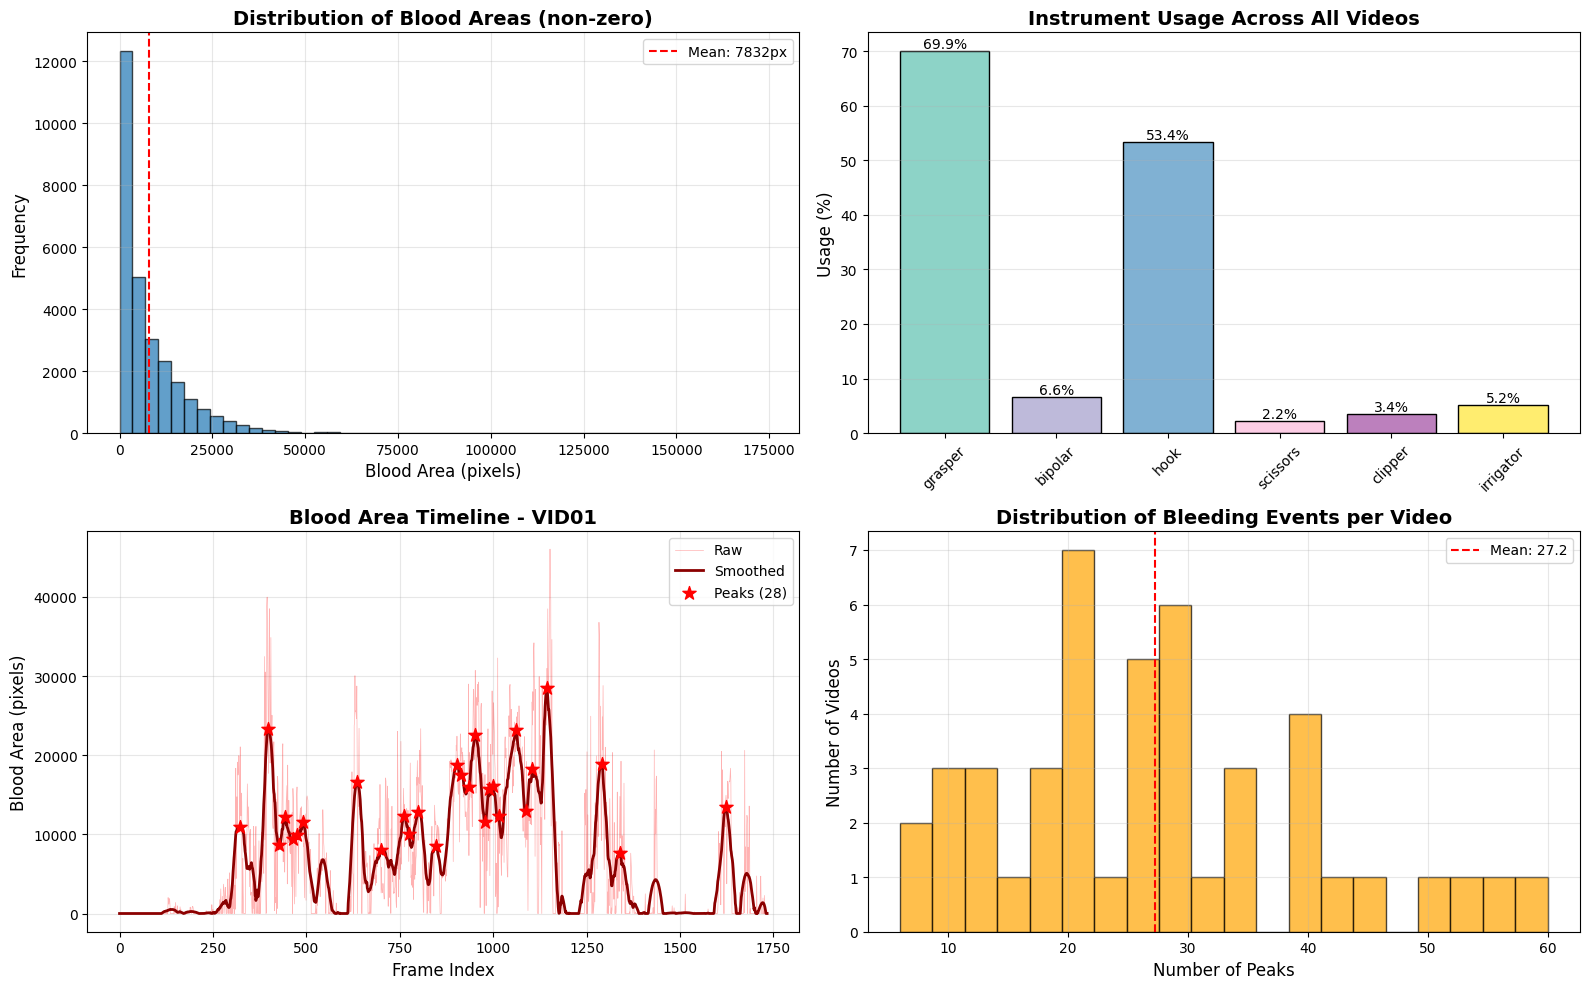

✅ Data distribution visualization saved


In [7]:
# Cell 6: Visualize Data Distribution
print("\nVisualizing data distributions...\n")

# Collect all blood areas and instrument usage
all_blood_areas = []
all_instrument_usage = np.zeros(Config.NUM_INSTRUMENTS)
total_frames = 0

for video_id, data in all_data.items():
    all_blood_areas.extend(data['blood_areas'])
    all_instrument_usage += np.sum(data['instrument_labels'], axis=0)
    total_frames += data['num_frames']

all_blood_areas = np.array(all_blood_areas)
instrument_names = all_data[list(all_data.keys())[0]]['instrument_names']

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Blood area distribution
axes[0, 0].hist(all_blood_areas[all_blood_areas > 0], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Blood Area (pixels)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of Blood Areas (non-zero)', fontsize=14, fontweight='bold')
axes[0, 0].axvline(np.mean(all_blood_areas[all_blood_areas > 0]), 
                   color='red', linestyle='--', label=f'Mean: {np.mean(all_blood_areas[all_blood_areas > 0]):.0f}px')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Instrument usage
usage_pct = 100 * all_instrument_usage / total_frames
colors = plt.cm.Set3(np.linspace(0, 1, len(instrument_names)))
bars = axes[0, 1].bar(instrument_names, usage_pct, color=colors, edgecolor='black')
axes[0, 1].set_ylabel('Usage (%)', fontsize=12)
axes[0, 1].set_title('Instrument Usage Across All Videos', fontsize=14, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Add values on bars
for bar, pct in zip(bars, usage_pct):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

# 3. Blood area over time (sample video)
sample_blood = sample_data['blood_areas']
sample_smoothed = sample_data['smoothed_blood_areas']
sample_peaks = sample_data['peaks']
sample_frames = sample_data['frame_indices']

axes[1, 0].plot(sample_frames, sample_blood, alpha=0.3, color='red', linewidth=0.5, label='Raw')
axes[1, 0].plot(sample_frames, sample_smoothed, color='darkred', linewidth=2, label='Smoothed')
if len(sample_peaks) > 0:
    axes[1, 0].scatter(sample_frames[sample_peaks], sample_smoothed[sample_peaks],
                      color='red', s=100, marker='*', zorder=5, label=f'Peaks ({len(sample_peaks)})')
axes[1, 0].set_xlabel('Frame Index', fontsize=12)
axes[1, 0].set_ylabel('Blood Area (pixels)', fontsize=12)
axes[1, 0].set_title(f'Blood Area Timeline - {sample_video}', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Peaks per video distribution
peaks_per_video = [len(data['peaks']) for data in all_data.values()]
axes[1, 1].hist(peaks_per_video, bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Number of Peaks', fontsize=12)
axes[1, 1].set_ylabel('Number of Videos', fontsize=12)
axes[1, 1].set_title('Distribution of Bleeding Events per Video', fontsize=14, fontweight='bold')
axes[1, 1].axvline(np.mean(peaks_per_video), color='red', linestyle='--', 
                  label=f'Mean: {np.mean(peaks_per_video):.1f}')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Config.OUTPUT_DIR / '01_data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Data distribution visualization saved")

---
# 🔄 SECTION 3: Temporal Feature Engineering
---

## Why Temporal Features?

Bleeding doesn't happen instantly - there's a buildup. By looking at multiple frames, the model can detect:

1. **Trends**: Is blood area increasing?
2. **Patterns**: Which instruments are consistently used?
3. **Acceleration**: Is the increase speeding up?

## Temporal Window Example:

```
Current frame: 500
Window: [495, 496, 497, 498, 499, 500]

Features created:
├── Basic (42 features)
│   ├── Frame 495: [inst1, inst2, ..., inst6, blood_area]
│   ├── Frame 496: [inst1, inst2, ..., inst6, blood_area]
│   ├── ...
│   └── Frame 500: [inst1, inst2, ..., inst6, blood_area]
│
├── Temporal changes (15 features)
│   ├── Blood changes: [Δ496, Δ497, Δ498, Δ499, Δ500]
│   ├── Blood velocities: [v496, v497, v498, v499, v500]
│   └── Blood accelerations: [a497, a498, a499, a500]
│
└── Total: 57 features
```

In [8]:
# Cell 7: Create Temporal Features Function
def create_temporal_features(video_data, window_size=6, include_temporal_changes=True):
    """
    Create temporal windowed features from video data
    
    Args:
        video_data: Dict with 'instrument_labels', 'blood_areas', 'peaks'
        window_size: Number of frames to include (current + previous)
        include_temporal_changes: Whether to add blood area changes
    
    Returns:
        features: (N, F) array where F = window_size * 7 [+ temporal features]
        labels: (N,) binary array (1 = bleeding will occur, 0 = no bleeding)
        valid_indices: Frame indices that have full windows
    """
    instrument_labels = video_data['instrument_labels']
    blood_areas = video_data['blood_areas']
    peaks = video_data['peaks']
    num_frames = len(blood_areas)
    
    # Combine instruments + blood into single feature vector per frame
    per_frame_features = np.column_stack([instrument_labels, blood_areas])  # (N, 7)
    
    # Create temporal windows
    features_list = []
    labels_list = []
    valid_indices = []
    
    # Start from window_size (need previous frames)
    for i in range(window_size - 1, num_frames):
        # Get window of frames [i-(window_size-1), ..., i]
        window_start = i - (window_size - 1)
        window_features = per_frame_features[window_start:i+1]  # (window_size, 7)
        
        # Flatten to 1D
        window_flat = window_features.flatten()  # (window_size * 7,)
        
        # Add temporal changes if requested
        if include_temporal_changes:
            blood_window = blood_areas[window_start:i+1]
            
            # Blood changes (absolute)
            blood_changes = np.diff(blood_window)  # (window_size - 1,)
            
            # Blood velocities (relative change)
            blood_velocities = np.zeros(window_size - 1)
            for j in range(len(blood_changes)):
                if blood_window[j] > 0:
                    blood_velocities[j] = blood_changes[j] / blood_window[j]
                else:
                    blood_velocities[j] = 0
            
            # Blood accelerations (change in velocity)
            blood_accelerations = np.diff(blood_velocities)  # (window_size - 2,)
            
            # Concatenate all
            temporal_features = np.concatenate([
                window_flat,
                blood_changes,
                blood_velocities,
                blood_accelerations
            ])
        else:
            temporal_features = window_flat
        
        features_list.append(temporal_features)
        valid_indices.append(i)
    
    # Convert to arrays
    features = np.array(features_list)
    valid_indices = np.array(valid_indices)
    
    print(f"  Created temporal features:")
    print(f"    Input frames: {num_frames:,}")
    print(f"    Valid samples (with full window): {len(features):,}")
    print(f"    Feature dimension: {features.shape[1]}")
    
    return features, valid_indices

# Test function
print("Testing temporal feature creation...\n")
test_features, test_indices = create_temporal_features(
    sample_data, 
    window_size=Config.WINDOW_SIZE,
    include_temporal_changes=True
)

print(f"\n✅ Temporal feature creation successful!")
print(f"   Shape: {test_features.shape}")
print(f"   Features: {test_features.shape[1]} dimensions")

Testing temporal feature creation...

  Created temporal features:
    Input frames: 1,734
    Valid samples (with full window): 1,729
    Feature dimension: 56

✅ Temporal feature creation successful!
   Shape: (1729, 56)
   Features: 56 dimensions


---
# 🎯 SECTION 4: Label Generation Strategy
---

## The Labeling Logic

We want to predict **"Will bleeding occur in the next 5 frames?"**

### Strategy:

For each detected peak (bleeding event) at frame `P`:
- Frames `[P-5, P-4, P-3, P-2, P-1]` → Label = **1** (bleeding will occur)
- Frame `P` → Label = **0** (already bleeding)
- All other frames → Label = **0** (no bleeding upcoming)

### Example:

```
Peak at frame 500:

Frame 490: Label = 0  (too far from peak)
Frame 491: Label = 0
...
Frame 495: Label = 1  ← 5 frames before peak
Frame 496: Label = 1  ← 4 frames before peak
Frame 497: Label = 1  ← 3 frames before peak
Frame 498: Label = 1  ← 2 frames before peak
Frame 499: Label = 1  ← 1 frame before peak
Frame 500: Label = 0  ← Peak itself (already bleeding)
Frame 501: Label = 0  (after peak)
...
```

### Why This Makes Sense:

1. **Early Warning**: We want to predict BEFORE the peak, not at/after
2. **Actionable**: 5 frames (~5 seconds at 1 FPS) gives surgeons time to react
3. **Realistic**: Bleeding builds up gradually, so frames before peak show warning signs

Minor and Major Peak Detector and Appropriate Labelling Strategy

In [13]:
# Cell 8: Major Bleeding Detection & Label Creation

# ============================================================================
# MAJOR BLEEDING DETECTOR CLASS
# ============================================================================
class MajorBleedingDetector:
    """
    Identifies clinically significant bleeding events from all detected peaks.
    """
    
    def __init__(
        self,
        min_blood_area=15000,        # Minimum peak blood area (pixels)
        min_prominence_ratio=2.5,    # Peak must be 2.5x baseline
        min_sustained_frames=3,      # Blood stays high for 3+ frames
        min_rate_of_increase=2000,   # Blood increases by 2000+ px/frame
        baseline_window=20           # Frames to compute baseline
    ):
        self.min_blood_area = min_blood_area
        self.min_prominence_ratio = min_prominence_ratio
        self.min_sustained_frames = min_sustained_frames
        self.min_rate_of_increase = min_rate_of_increase
        self.baseline_window = baseline_window
    
    def compute_baseline(self, blood_areas, peak_idx):
        """Compute baseline blood area before peak"""
        start_idx = max(0, peak_idx - self.baseline_window - 10)
        end_idx = max(0, peak_idx - 10)  # Exclude 10 frames before peak
        
        if end_idx <= start_idx:
            return 0
        
        baseline_area = blood_areas[start_idx:end_idx]
        return np.median(baseline_area[baseline_area > 0]) if len(baseline_area[baseline_area > 0]) > 0 else 0
    
    def check_sustained_elevation(self, blood_areas, peak_idx):
        """Check if blood remains elevated after peak"""
        end_idx = min(len(blood_areas), peak_idx + self.min_sustained_frames + 1)
        window = blood_areas[peak_idx:end_idx]
        
        peak_value = blood_areas[peak_idx]
        sustained_count = np.sum(window > 0.7 * peak_value)
        
        return sustained_count >= self.min_sustained_frames
    
    def compute_rate_of_increase(self, blood_areas, peak_idx):
        """Compute average rate of blood increase leading to peak"""
        start_idx = max(0, peak_idx - 5)
        window = blood_areas[start_idx:peak_idx + 1]
        
        if len(window) < 2:
            return 0
        
        rate = (window[-1] - window[0]) / len(window)
        return rate
    
    def is_major_bleeding(self, blood_areas, peak_idx):
        """Determine if a peak represents a MAJOR bleeding event."""
        peak_value = blood_areas[peak_idx]
        
        # Criterion 1: Absolute threshold
        criterion_1 = peak_value >= self.min_blood_area
        
        # Criterion 2: Prominence (relative to baseline)
        baseline = self.compute_baseline(blood_areas, peak_idx)
        if baseline > 0:
            prominence_ratio = peak_value / baseline
        else:
            prominence_ratio = float('inf') if peak_value > 0 else 0
        criterion_2 = prominence_ratio >= self.min_prominence_ratio
        
        # Criterion 3: Sustained elevation
        criterion_3 = self.check_sustained_elevation(blood_areas, peak_idx)
        
        # Criterion 4: Rate of increase
        rate = self.compute_rate_of_increase(blood_areas, peak_idx)
        criterion_4 = rate >= self.min_rate_of_increase
        
        # Decision: Require at least 3 out of 4 criteria
        criteria_met = sum([criterion_1, criterion_2, criterion_3, criterion_4])
        is_major = criteria_met >= 3
        
        details = {
            'peak_value': peak_value,
            'baseline': baseline,
            'prominence_ratio': prominence_ratio,
            'rate_of_increase': rate,
            'criteria_met': criteria_met,
            'criterion_1_absolute': criterion_1,
            'criterion_2_prominence': criterion_2,
            'criterion_3_sustained': criterion_3,
            'criterion_4_rate': criterion_4
        }
        
        return is_major, criteria_met, details
    
    def filter_major_peaks(self, blood_areas, all_peaks):
        """Filter all detected peaks to keep only MAJOR bleeding events."""
        major_peaks = []
        peak_details = []
        
        for peak_idx in all_peaks:
            is_major, criteria_met, details = self.is_major_bleeding(blood_areas, peak_idx)
            
            details['is_major'] = is_major
            peak_details.append(details)
            
            if is_major:
                major_peaks.append(peak_idx)
        
        return np.array(major_peaks), peak_details


# ============================================================================
# CREATE LABELS FUNCTION (UPDATED)
# ============================================================================
def create_labels(valid_indices, peaks, prediction_horizon=5):
    """
    Create binary labels: 1 if bleeding will occur in next N frames, 0 otherwise
    
    Args:
        valid_indices: Frame indices that have valid features
        peaks: Array of peak frame indices (MAJOR peaks only after filtering)
        prediction_horizon: How many frames ahead to predict
    
    Returns:
        labels: Binary array (1 = bleeding will occur, 0 = no bleeding)
    """
    labels = np.zeros(len(valid_indices), dtype=int)
    
    # For each peak, label the N frames before it as positive
    for peak in peaks:
        # Find frames that are 1-N frames before this peak
        for offset in range(1, prediction_horizon + 1):
            target_frame = peak - offset
            
            # Find if this frame is in our valid indices
            mask = valid_indices == target_frame
            if np.any(mask):
                labels[mask] = 1
    
    return labels


# ============================================================================
# INITIALIZE DETECTOR & TEST
# ============================================================================
print("Initializing Major Bleeding Detector...\n")

# Create detector (adjust thresholds based on your data scale)
detector = MajorBleedingDetector(
    min_blood_area=15000,         # Adjust based on your blood area scale
    min_prominence_ratio=2.5,     # Peak must be 2.5x baseline
    min_sustained_frames=3,       # Blood stays high for 3 frames
    min_rate_of_increase=2000,    # Rapid increase threshold
    baseline_window=20            # Baseline computation window
)

print(f"Detector parameters:")
print(f"  Min blood area: {detector.min_blood_area:,} pixels")
print(f"  Min prominence ratio: {detector.min_prominence_ratio}x")
print(f"  Min sustained frames: {detector.min_sustained_frames}")
print(f"  Min rate of increase: {detector.min_rate_of_increase:,} px/frame")

# Filter peaks for sample video
print(f"\n{'='*80}")
print("TESTING MAJOR BLEEDING FILTER")
print(f"{'='*80}\n")

all_peaks = sample_data['peaks']
major_peaks, peak_details = detector.filter_major_peaks(
    sample_data['smoothed_blood_areas'],
    all_peaks
)

print(f"Sample Video Analysis:")
print(f"  Total peaks detected: {len(all_peaks)}")
print(f"  MAJOR bleeding events: {len(major_peaks)}")
print(f"  Minor peaks (filtered out): {len(all_peaks) - len(major_peaks)}")
print(f"  Filter rate: {100 * (len(all_peaks) - len(major_peaks)) / len(all_peaks):.1f}% of peaks excluded")

# Show details of first few peaks
print(f"\nPeak Classification Details (first 5):")
for i, (peak_idx, details) in enumerate(zip(all_peaks[:5], peak_details[:5])):
    status = "✅ MAJOR" if details['is_major'] else "❌ MINOR"
    print(f"\nPeak {i+1} at frame {peak_idx}: {status}")
    print(f"  Blood area: {details['peak_value']:.0f} px (threshold: {detector.min_blood_area:,})")
    print(f"  Prominence: {details['prominence_ratio']:.2f}x (threshold: {detector.min_prominence_ratio}x)")
    print(f"  Rate: {details['rate_of_increase']:.0f} px/frame (threshold: {detector.min_rate_of_increase:,})")
    print(f"  Criteria met: {details['criteria_met']}/4")

# Test label creation with MAJOR peaks only
print(f"\n{'='*80}")
print("TESTING LABEL CREATION (MAJOR PEAKS ONLY)")
print(f"{'='*80}\n")

test_labels = create_labels(
    test_indices, 
    major_peaks,  # ← Using filtered major peaks instead of all peaks
    prediction_horizon=Config.PREDICTION_HORIZON
)

print(f"Label Statistics:")
print(f"  Total samples: {len(test_labels):,}")
print(f"  Positive (major bleeding will occur): {np.sum(test_labels):,} ({100*np.mean(test_labels):.2f}%)")
print(f"  Negative (safe/no major bleeding): {np.sum(test_labels == 0):,} ({100*np.mean(test_labels == 0):.2f}%)")
print(f"  Class imbalance ratio: 1:{np.sum(test_labels == 0) / max(np.sum(test_labels), 1):.1f}")

print(f"\nComparison (if all peaks were used):")
test_labels_all = create_labels(test_indices, all_peaks, Config.PREDICTION_HORIZON)
print(f"  Positive (all peaks): {np.sum(test_labels_all):,} ({100*np.mean(test_labels_all):.2f}%)")
print(f"  Reduction in positive labels: {100 * (1 - np.sum(test_labels) / np.sum(test_labels_all)):.1f}%")

print(f"\n✅ Major bleeding detection and label creation successful!")

Initializing Major Bleeding Detector...

Detector parameters:
  Min blood area: 15,000 pixels
  Min prominence ratio: 2.5x
  Min sustained frames: 3
  Min rate of increase: 2,000 px/frame

TESTING MAJOR BLEEDING FILTER

Sample Video Analysis:
  Total peaks detected: 28
  MAJOR bleeding events: 3
  Minor peaks (filtered out): 25
  Filter rate: 89.3% of peaks excluded

Peak Classification Details (first 5):

Peak 1 at frame 323: ❌ MINOR
  Blood area: 10924 px (threshold: 15,000)
  Prominence: 2.63x (threshold: 2.5x)
  Rate: 49 px/frame (threshold: 2,000)
  Criteria met: 2/4

Peak 2 at frame 397: ✅ MAJOR
  Blood area: 23358 px (threshold: 15,000)
  Prominence: 4.88x (threshold: 2.5x)
  Rate: 496 px/frame (threshold: 2,000)
  Criteria met: 3/4

Peak 3 at frame 428: ❌ MINOR
  Blood area: 8620 px (threshold: 15,000)
  Prominence: 0.42x (threshold: 2.5x)
  Rate: -93 px/frame (threshold: 2,000)
  Criteria met: 1/4

Peak 4 at frame 443: ❌ MINOR
  Blood area: 12146 px (threshold: 15,000)
  Promi

Old Labelling Strategy

In [9]:
# Cell 8: Create Labels Function
def create_labels(valid_indices, peaks, prediction_horizon=5):
    """
    Create binary labels: 1 if bleeding will occur in next N frames, 0 otherwise
    
    Args:
        valid_indices: Frame indices that have valid features
        peaks: Array of peak frame indices
        prediction_horizon: How many frames ahead to predict
    
    Returns:
        labels: Binary array (1 = bleeding will occur, 0 = no bleeding)
    """
    labels = np.zeros(len(valid_indices), dtype=int)
    
    # For each peak, label the N frames before it as positive
    for peak in peaks:
        # Find frames that are 1-N frames before this peak
        for offset in range(1, prediction_horizon + 1):
            target_frame = peak - offset
            
            # Find if this frame is in our valid indices
            mask = valid_indices == target_frame
            if np.any(mask):
                labels[mask] = 1
    
    return labels

# Test label creation
print("Testing label creation...\n")
test_labels = create_labels(
    test_indices, 
    sample_data['peaks'],
    prediction_horizon=Config.PREDICTION_HORIZON
)

print(f"  Total samples: {len(test_labels):,}")
print(f"  Positive (bleeding will occur): {np.sum(test_labels):,} ({100*np.mean(test_labels):.2f}%)")
print(f"  Negative (no bleeding): {np.sum(test_labels == 0):,} ({100*np.mean(test_labels == 0):.2f}%)")
print(f"  Class imbalance ratio: 1:{np.sum(test_labels == 0) / max(np.sum(test_labels), 1):.1f}")

print(f"\n✅ Label creation successful!")

Testing label creation...

  Total samples: 1,729
  Positive (bleeding will occur): 140 (8.10%)
  Negative (no bleeding): 1,589 (91.90%)
  Class imbalance ratio: 1:11.3

✅ Label creation successful!



Visualizing labeling strategy...



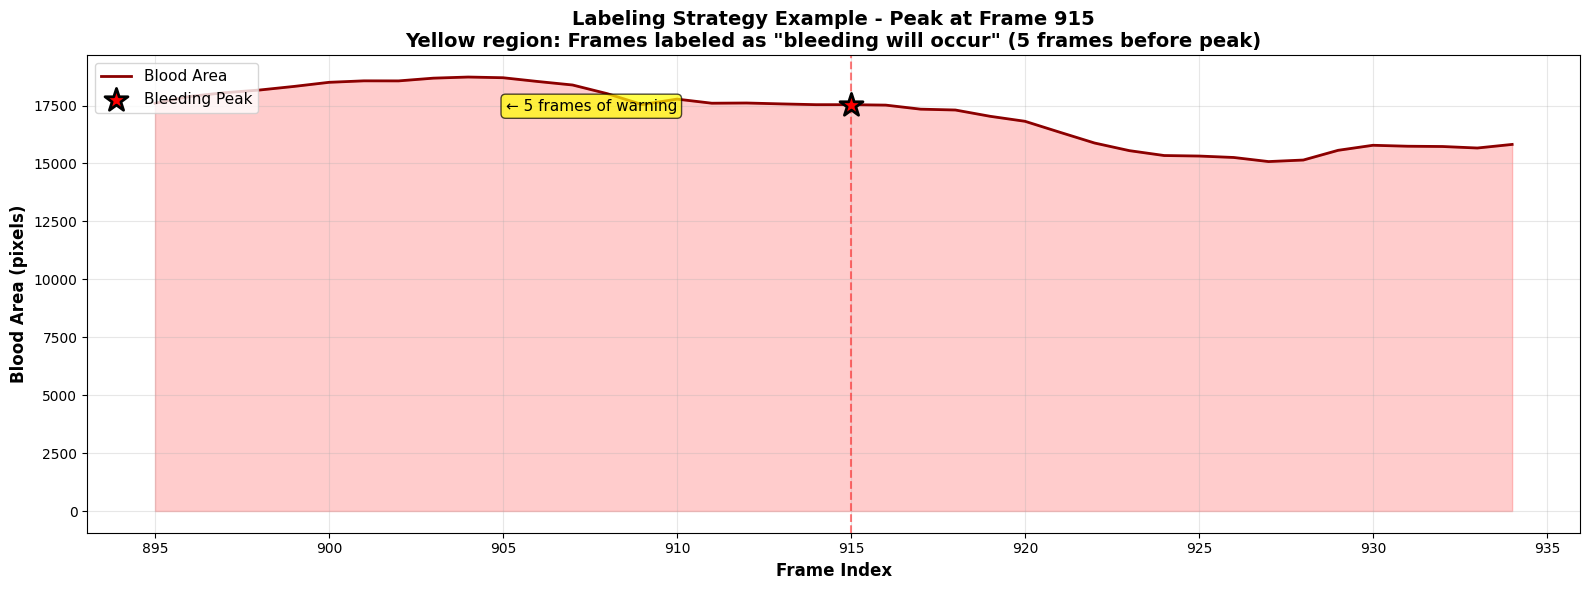

✅ Labeling strategy visualization saved


In [14]:
# Cell 9: Visualize Labeling Strategy
print("\nVisualizing labeling strategy...\n")

# Pick a peak to visualize
if len(sample_data['peaks']) > 0:
    peak_idx = sample_data['peaks'][len(sample_data['peaks'])//2]  # Middle peak
    
    # Get window around peak
    window_start = max(0, peak_idx - 20)
    window_end = min(len(sample_data['blood_areas']), peak_idx + 20)
    
    window_frames = sample_data['frame_indices'][window_start:window_end]
    window_blood = sample_data['smoothed_blood_areas'][window_start:window_end]
    
    # Determine labels for this window
    window_labels = np.zeros(len(window_frames))
    for i, frame in enumerate(window_frames):
        if frame in test_indices:
            idx = np.where(test_indices == frame)[0][0]
            window_labels[i] = test_labels[idx]
    
    # Plot
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # Blood area
    ax.plot(window_frames, window_blood, color='darkred', linewidth=2, label='Blood Area')
    ax.fill_between(window_frames, 0, window_blood, alpha=0.2, color='red')
    
    # Highlight labeled regions
    positive_mask = window_labels == 1
    if np.any(positive_mask):
        ax.fill_between(window_frames, 0, window_blood.max() * 1.1, 
                       where=positive_mask, alpha=0.3, color='yellow',
                       label=f'Positive Labels (bleeding in {Config.PREDICTION_HORIZON} frames)')
    
    # Mark peak
    peak_pos = np.where(window_frames == peak_idx)[0]
    if len(peak_pos) > 0:
        ax.scatter(peak_idx, window_blood[peak_pos[0]], 
                  color='red', s=300, marker='*', zorder=5,
                  edgecolors='black', linewidths=2, label='Bleeding Peak')
        ax.axvline(peak_idx, color='red', linestyle='--', alpha=0.5)
    
    # Annotations
    ax.set_xlabel('Frame Index', fontsize=12, fontweight='bold')
    ax.set_ylabel('Blood Area (pixels)', fontsize=12, fontweight='bold')
    ax.set_title(f'Labeling Strategy Example - Peak at Frame {peak_idx}\n'
                f'Yellow region: Frames labeled as "bleeding will occur" (5 frames before peak)',
                fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Add text annotations
    ax.text(peak_idx - Config.PREDICTION_HORIZON, window_blood.max() * 0.95,
           f'← {Config.PREDICTION_HORIZON} frames of warning',
           fontsize=11, ha='right', va='top',
           bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    plt.tight_layout()
    plt.savefig(Config.OUTPUT_DIR / '02_labeling_strategy.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Labeling strategy visualization saved")
else:
    print("⚠️  No peaks in sample video to visualize")

New Visualization - Minor and Major Peaks


Visualizing labeling strategy...

Creating major vs minor peak classification plot...


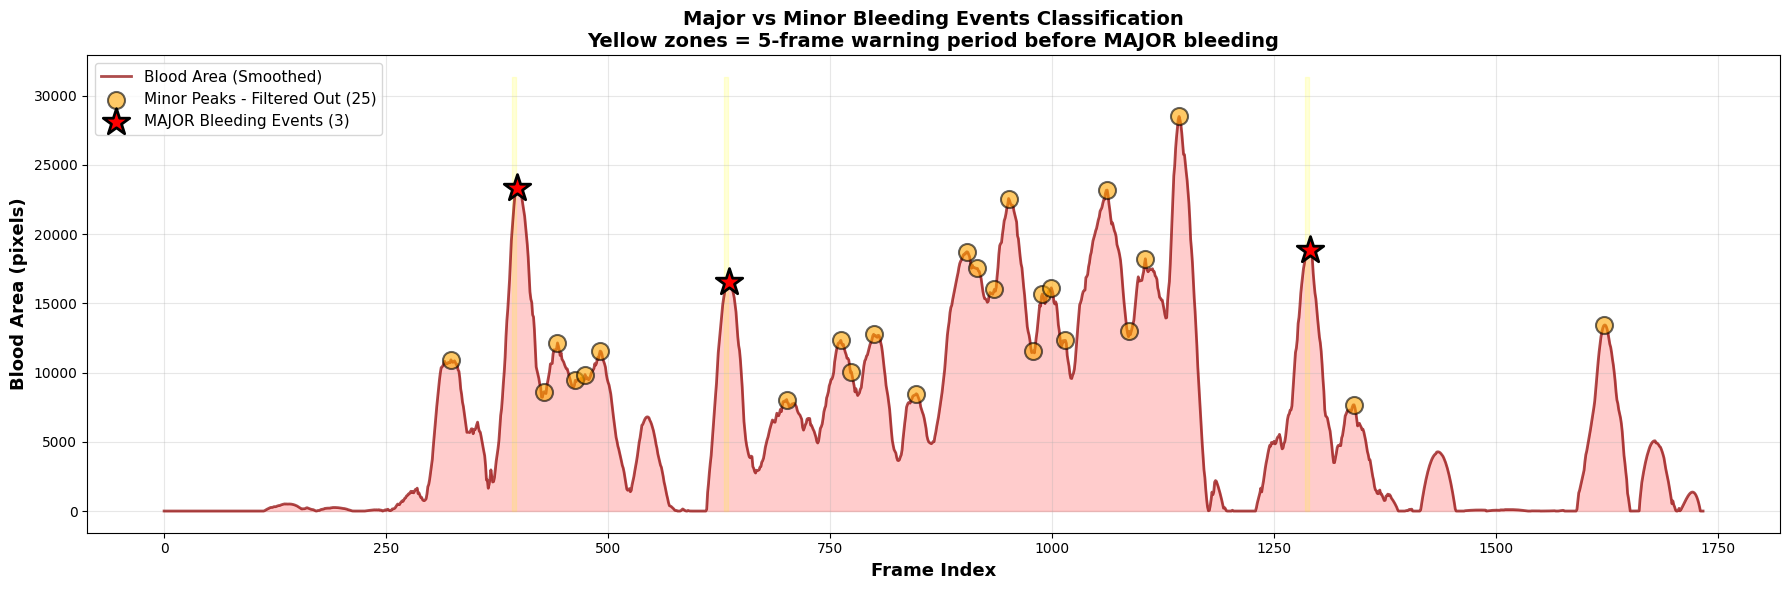

✅ Major vs minor classification visualization saved

Creating detailed labeling examples for multiple peaks...


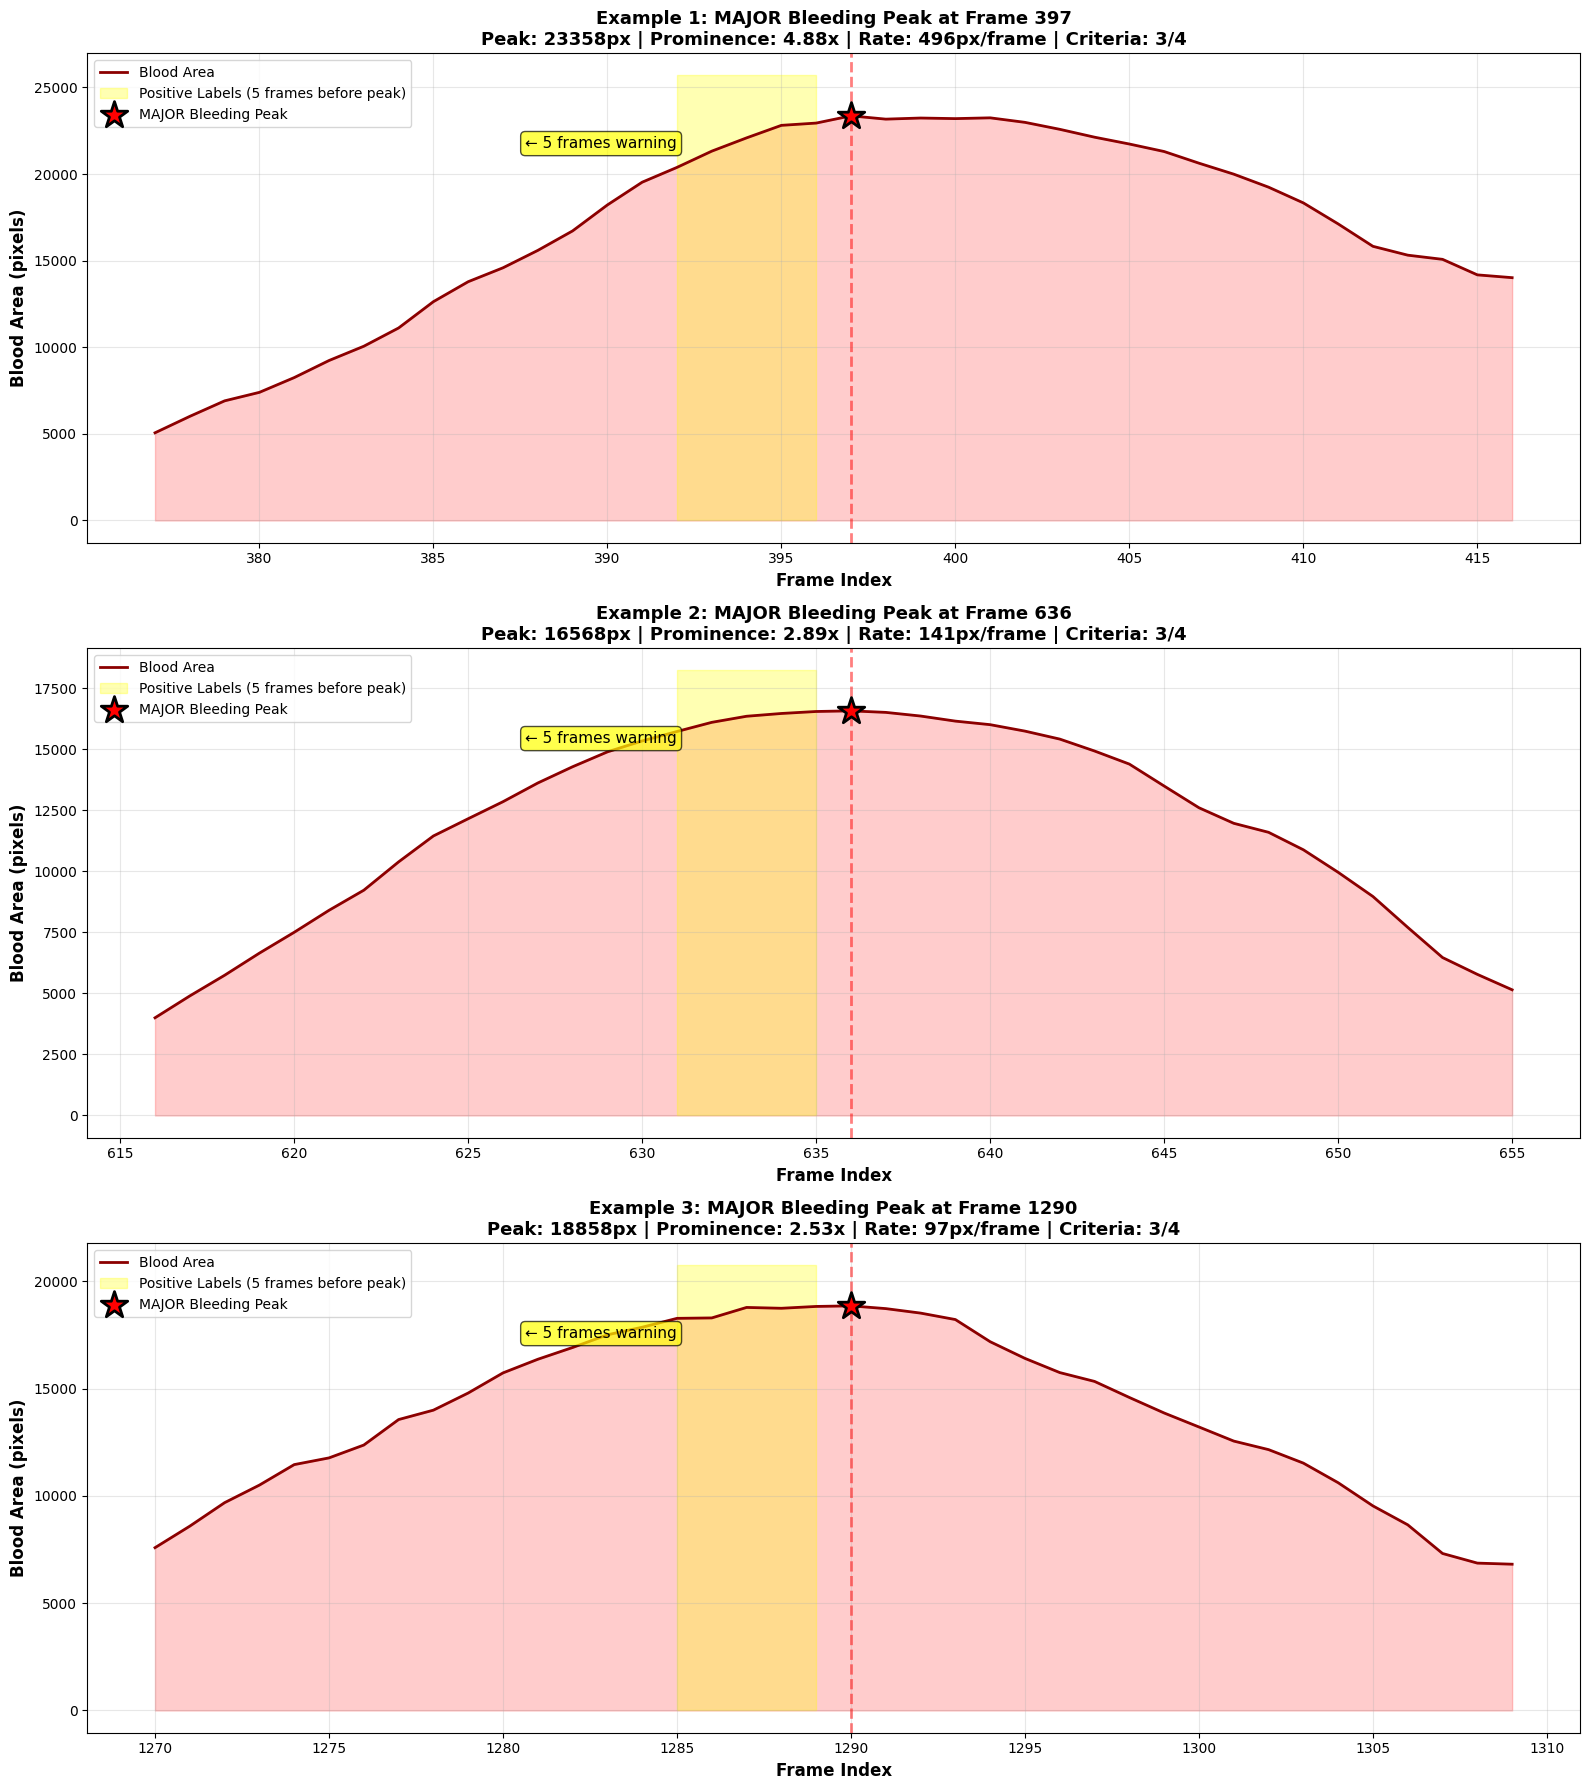

✅ Labeling strategy examples saved (3 peaks shown)

Creating comparison with filtered minor peaks...


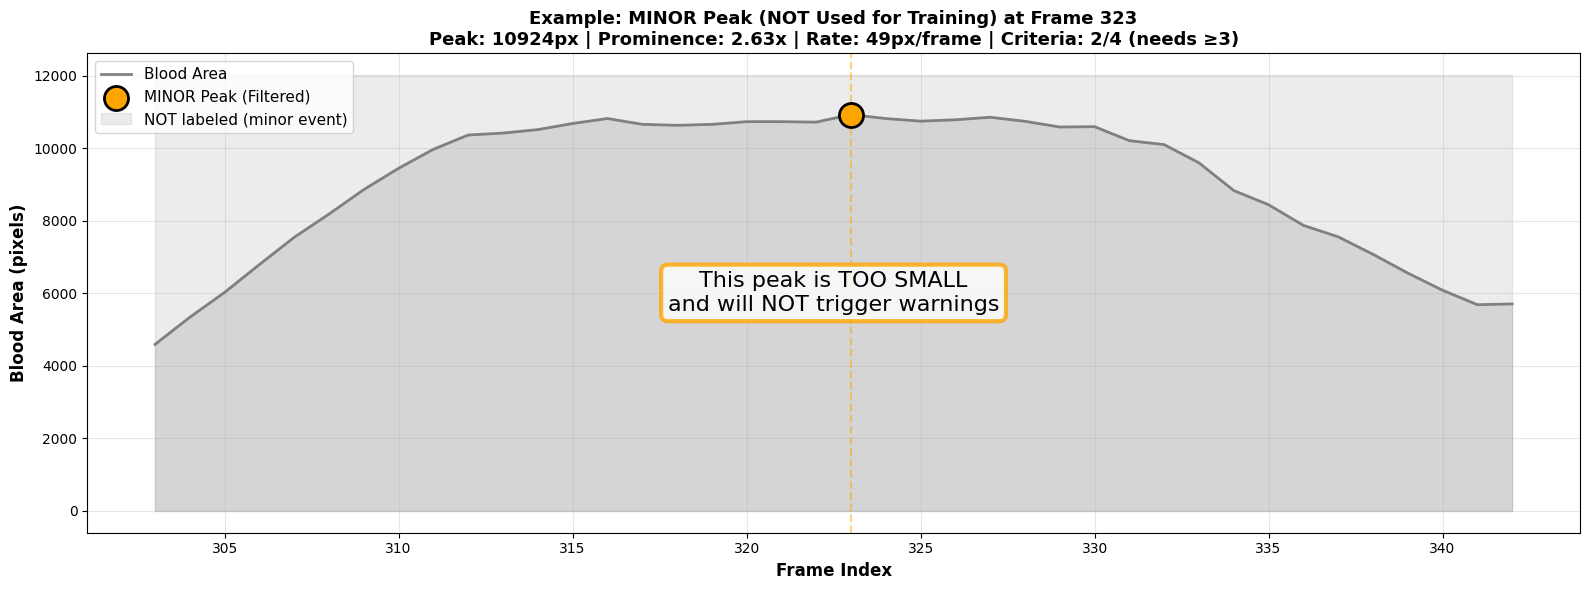

✅ Minor peak example saved (showing what we filter out)

VISUALIZATION SUMMARY
✅ Created 3 visualizations:
   1. Major vs Minor peak classification (full timeline)
   2. Detailed labeling examples (3 major peaks)
   3. Minor peak example (what we filter out)

All saved to: bleeding_prediction_model/


In [15]:
# Cell 9: Visualize Labeling Strategy (ENHANCED)
print("\nVisualizing labeling strategy...\n")

# ============================================================================
# VISUALIZATION 1: Major vs Minor Peak Classification
# ============================================================================
print("Creating major vs minor peak classification plot...")

if len(sample_data['peaks']) > 0:
    fig, ax = plt.subplots(figsize=(18, 6))
    
    blood_areas = sample_data['smoothed_blood_areas']
    frame_indices = sample_data['frame_indices']
    
    # Plot blood area curve
    ax.plot(frame_indices, blood_areas, color='darkred', linewidth=2, 
            label='Blood Area (Smoothed)', alpha=0.7)
    ax.fill_between(frame_indices, 0, blood_areas, alpha=0.2, color='red')
    
    # Separate major and minor peaks
    minor_peaks = [p for p in all_peaks if p not in major_peaks]
    
    # Mark minor peaks (orange circles)
    if len(minor_peaks) > 0:
        ax.scatter(frame_indices[minor_peaks], blood_areas[minor_peaks],
                  color='orange', s=150, marker='o', alpha=0.6,
                  edgecolors='black', linewidths=1.5,
                  label=f'Minor Peaks - Filtered Out ({len(minor_peaks)})', zorder=3)
    
    # Mark MAJOR peaks (red stars)
    if len(major_peaks) > 0:
        ax.scatter(frame_indices[major_peaks], blood_areas[major_peaks],
                  color='red', s=400, marker='*', 
                  edgecolors='black', linewidths=2,
                  label=f'MAJOR Bleeding Events ({len(major_peaks)})', zorder=5)
    
    # Highlight warning zones (5 frames before major peaks)
    for peak in major_peaks:
        warning_start = max(0, peak - Config.PREDICTION_HORIZON)
        warning_end = peak
        warning_frames = frame_indices[warning_start:warning_end]
        ax.fill_between(warning_frames, 0, blood_areas.max() * 1.1,
                       alpha=0.15, color='yellow', zorder=1)
    
    ax.set_xlabel('Frame Index', fontsize=13, fontweight='bold')
    ax.set_ylabel('Blood Area (pixels)', fontsize=13, fontweight='bold')
    ax.set_title('Major vs Minor Bleeding Events Classification\n'
                 f'Yellow zones = {Config.PREDICTION_HORIZON}-frame warning period before MAJOR bleeding',
                 fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(Config.OUTPUT_DIR / '02a_major_vs_minor_peaks.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Major vs minor classification visualization saved")

# ============================================================================
# VISUALIZATION 2: Detailed Labeling Examples (Multiple Peaks)
# ============================================================================
print("\nCreating detailed labeling examples for multiple peaks...")

if len(major_peaks) > 0:
    # Select up to 3 major peaks to visualize
    num_examples = min(3, len(major_peaks))
    peak_indices_to_show = [
        major_peaks[0],                              # First major peak
        major_peaks[len(major_peaks)//2],           # Middle major peak
        major_peaks[-1]                              # Last major peak
    ][:num_examples]
    
    fig, axes = plt.subplots(num_examples, 1, figsize=(16, 6*num_examples))
    if num_examples == 1:
        axes = [axes]  # Make it iterable
    
    for idx, (ax, peak_idx) in enumerate(zip(axes, peak_indices_to_show)):
        # Get window around peak
        window_start = max(0, peak_idx - 20)
        window_end = min(len(sample_data['blood_areas']), peak_idx + 20)
        
        window_frames = sample_data['frame_indices'][window_start:window_end]
        window_blood = sample_data['smoothed_blood_areas'][window_start:window_end]
        
        # Determine labels for this window
        window_labels = np.zeros(len(window_frames))
        for i, frame in enumerate(window_frames):
            if frame in test_indices:
                idx_in_test = np.where(test_indices == frame)[0][0]
                window_labels[i] = test_labels[idx_in_test]
        
        # Plot blood area
        ax.plot(window_frames, window_blood, color='darkred', linewidth=2, label='Blood Area')
        ax.fill_between(window_frames, 0, window_blood, alpha=0.2, color='red')
        
        # Highlight labeled regions (positive labels)
        positive_mask = window_labels == 1
        if np.any(positive_mask):
            ax.fill_between(window_frames, 0, window_blood.max() * 1.1, 
                           where=positive_mask, alpha=0.3, color='yellow',
                           label=f'Positive Labels ({Config.PREDICTION_HORIZON} frames before peak)')
        
        # Mark the major peak
        peak_pos = np.where(window_frames == peak_idx)[0]
        if len(peak_pos) > 0:
            ax.scatter(peak_idx, window_blood[peak_pos[0]], 
                      color='red', s=400, marker='*', zorder=5,
                      edgecolors='black', linewidths=2, label='MAJOR Bleeding Peak')
            ax.axvline(peak_idx, color='red', linestyle='--', alpha=0.5, linewidth=2)
        
        # Get peak details
        peak_detail_idx = np.where(all_peaks == peak_idx)[0][0]
        details = peak_details[peak_detail_idx]
        
        # Annotations
        ax.set_xlabel('Frame Index', fontsize=12, fontweight='bold')
        ax.set_ylabel('Blood Area (pixels)', fontsize=12, fontweight='bold')
        ax.set_title(f'Example {idx+1}: MAJOR Bleeding Peak at Frame {peak_idx}\n'
                    f'Peak: {details["peak_value"]:.0f}px | '
                    f'Prominence: {details["prominence_ratio"]:.2f}x | '
                    f'Rate: {details["rate_of_increase"]:.0f}px/frame | '
                    f'Criteria: {details["criteria_met"]}/4',
                    fontsize=13, fontweight='bold')
        ax.legend(loc='upper left', fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # Add warning zone annotation
        if np.any(positive_mask):
            ax.text(peak_idx - Config.PREDICTION_HORIZON, window_blood.max() * 0.95,
                   f'← {Config.PREDICTION_HORIZON} frames warning',
                   fontsize=11, ha='right', va='top',
                   bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    plt.tight_layout()
    plt.savefig(Config.OUTPUT_DIR / '02b_labeling_strategy_examples.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Labeling strategy examples saved ({num_examples} peaks shown)")

# ============================================================================
# VISUALIZATION 3: Comparison - What We're NOT Predicting (Minor Peaks)
# ============================================================================
print("\nCreating comparison with filtered minor peaks...")

minor_peaks = [p for p in all_peaks if p not in major_peaks]

if len(minor_peaks) > 0:
    # Show first minor peak as example
    minor_peak_idx = minor_peaks[0]
    
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # Get window around minor peak
    window_start = max(0, minor_peak_idx - 20)
    window_end = min(len(sample_data['blood_areas']), minor_peak_idx + 20)
    
    window_frames = sample_data['frame_indices'][window_start:window_end]
    window_blood = sample_data['smoothed_blood_areas'][window_start:window_end]
    
    # Plot
    ax.plot(window_frames, window_blood, color='gray', linewidth=2, label='Blood Area')
    ax.fill_between(window_frames, 0, window_blood, alpha=0.2, color='gray')
    
    # Mark the minor peak
    peak_pos = np.where(window_frames == minor_peak_idx)[0]
    if len(peak_pos) > 0:
        ax.scatter(minor_peak_idx, window_blood[peak_pos[0]], 
                  color='orange', s=300, marker='o', zorder=5,
                  edgecolors='black', linewidths=2, label='MINOR Peak (Filtered)')
        ax.axvline(minor_peak_idx, color='orange', linestyle='--', alpha=0.5)
    
    # Get minor peak details
    minor_peak_detail_idx = np.where(all_peaks == minor_peak_idx)[0][0]
    minor_details = peak_details[minor_peak_detail_idx]
    
    # Add "NOT LABELED" region
    ax.fill_between(window_frames, 0, window_blood.max() * 1.1,
                   alpha=0.15, color='gray',
                   label='NOT labeled (minor event)')
    
    ax.set_xlabel('Frame Index', fontsize=12, fontweight='bold')
    ax.set_ylabel('Blood Area (pixels)', fontsize=12, fontweight='bold')
    ax.set_title(f'Example: MINOR Peak (NOT Used for Training) at Frame {minor_peak_idx}\n'
                f'Peak: {minor_details["peak_value"]:.0f}px | '
                f'Prominence: {minor_details["prominence_ratio"]:.2f}x | '
                f'Rate: {minor_details["rate_of_increase"]:.0f}px/frame | '
                f'Criteria: {minor_details["criteria_met"]}/4 (needs ≥3)',
                fontsize=13, fontweight='bold')
    ax.legend(loc='upper left', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Add explanation text
    ax.text(0.5, 0.5, 'This peak is TOO SMALL\nand will NOT trigger warnings',
           transform=ax.transAxes, fontsize=16, ha='center', va='center',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='orange', linewidth=3))
    
    plt.tight_layout()
    plt.savefig(Config.OUTPUT_DIR / '02c_minor_peak_example.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Minor peak example saved (showing what we filter out)")
else:
    print("⚠️ No minor peaks to visualize (all peaks are major!)")

print("\n" + "="*80)
print("VISUALIZATION SUMMARY")
print("="*80)
print(f"✅ Created 3 visualizations:")
print(f"   1. Major vs Minor peak classification (full timeline)")
print(f"   2. Detailed labeling examples ({min(3, len(major_peaks))} major peaks)")
print(f"   3. Minor peak example (what we filter out)")
print(f"\nAll saved to: {Config.OUTPUT_DIR}/")

Visualization over an entire video


Visualizing labeling strategy over ENTIRE video...

Creating comprehensive full-video visualization...


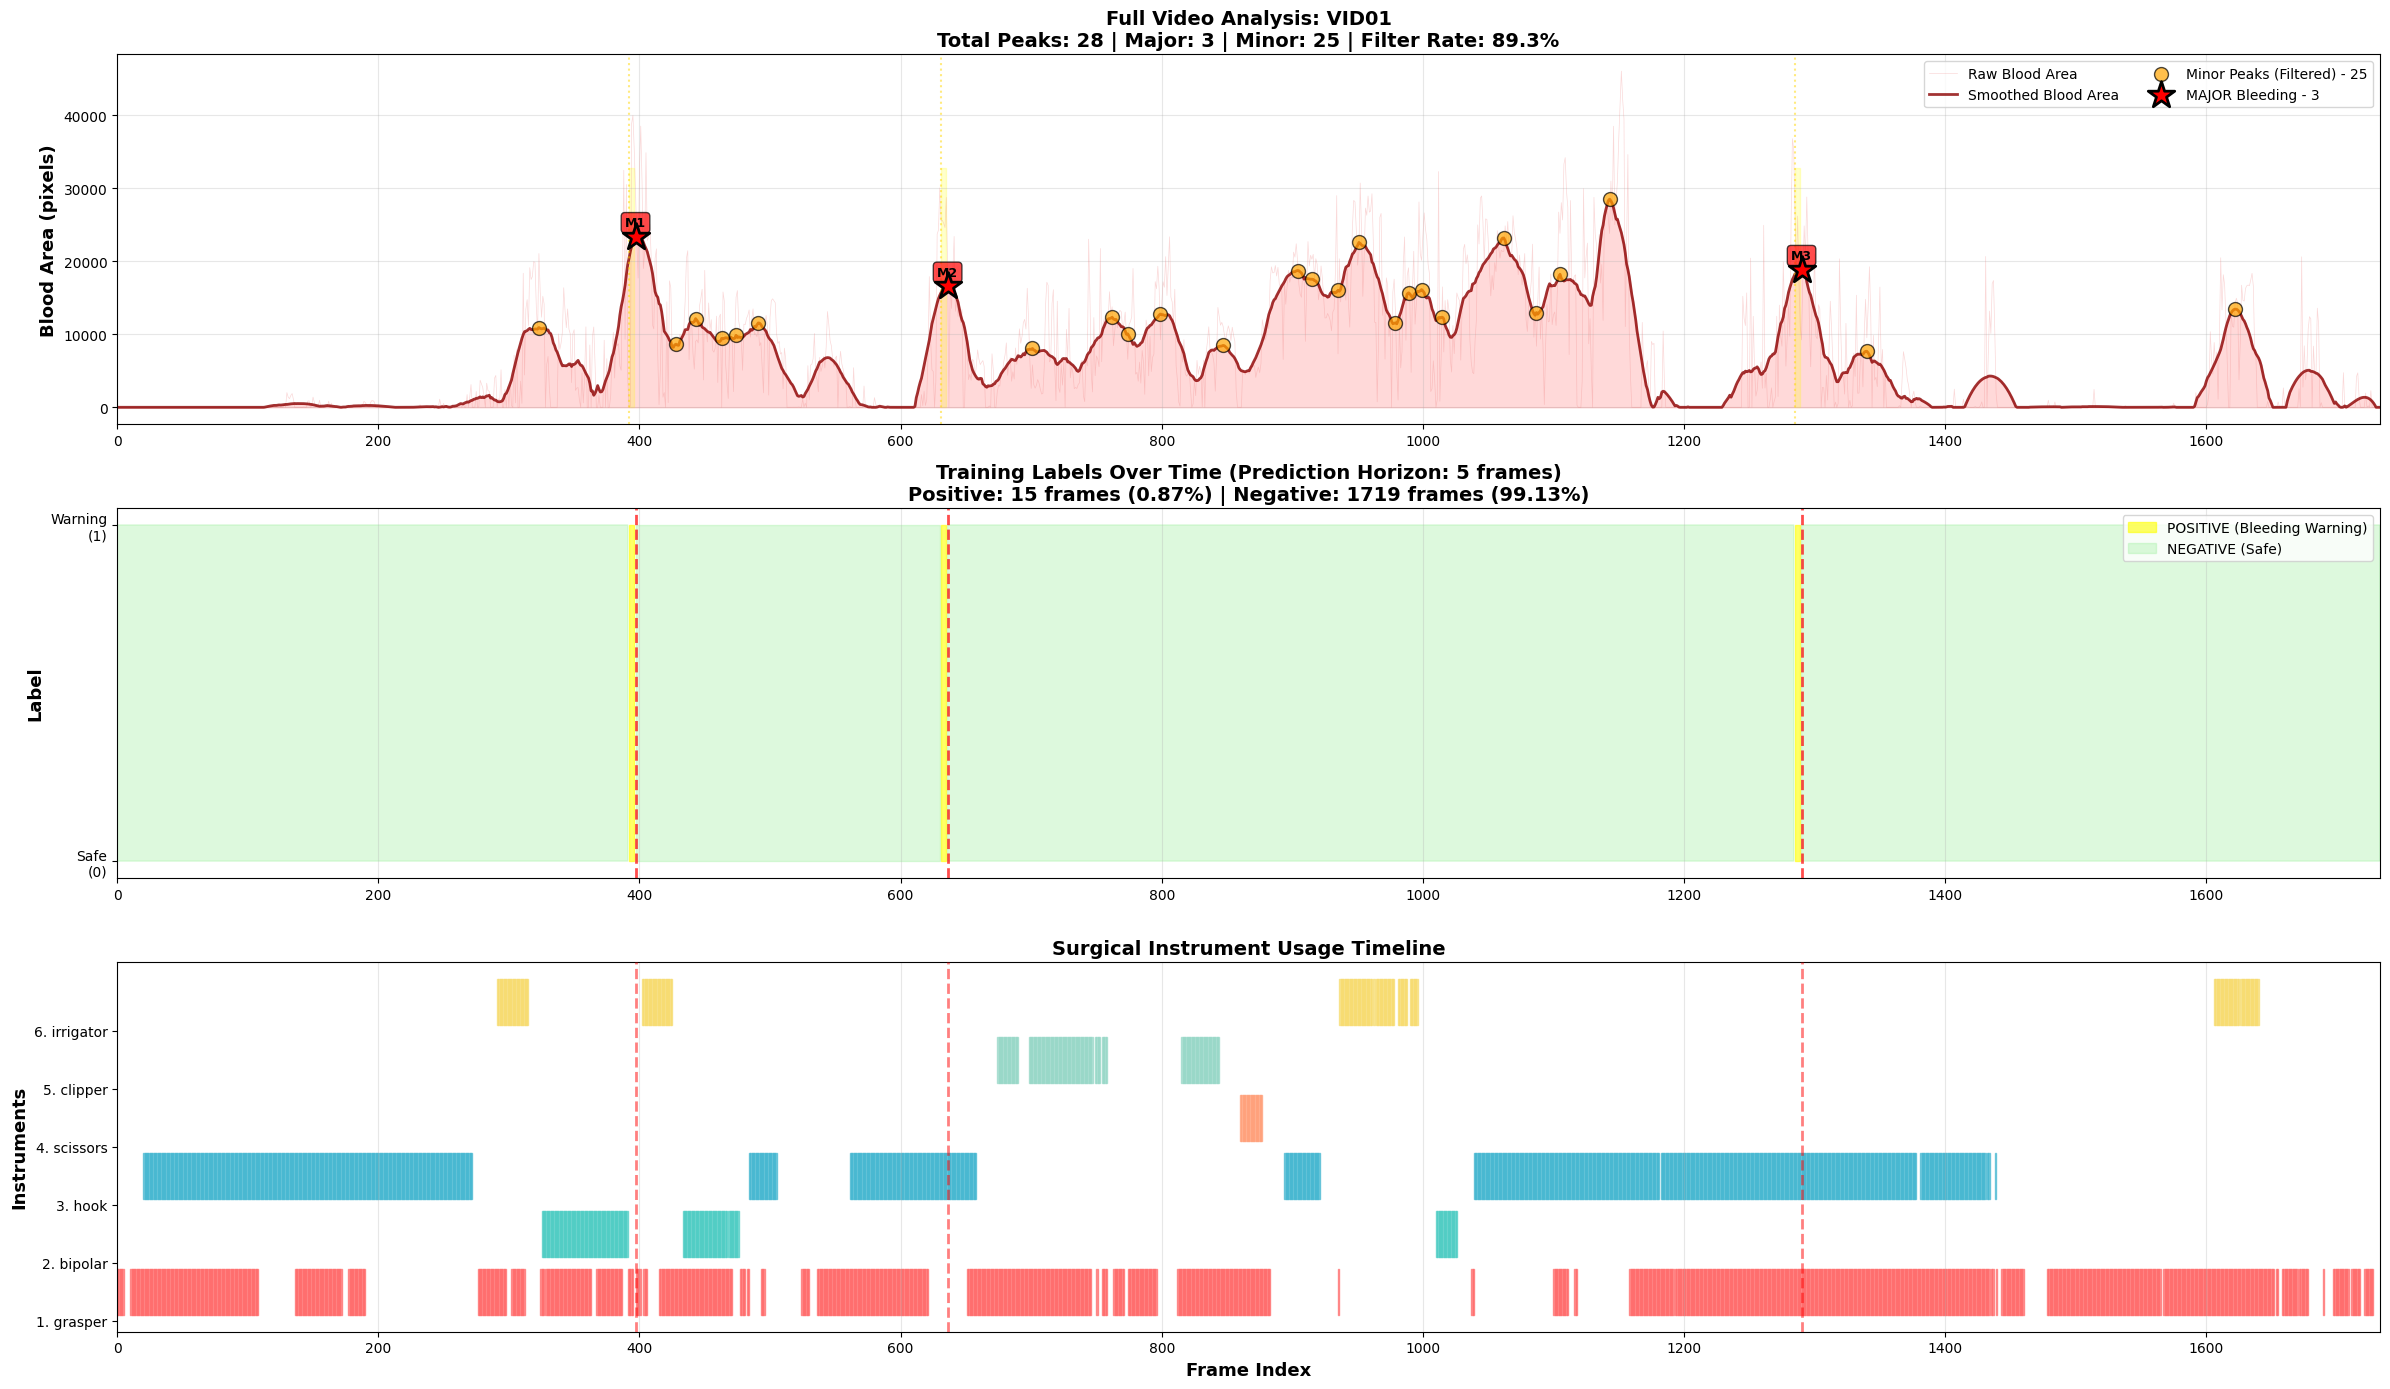

✅ Full video overview saved

Creating detailed views of all 3 major bleeding events...


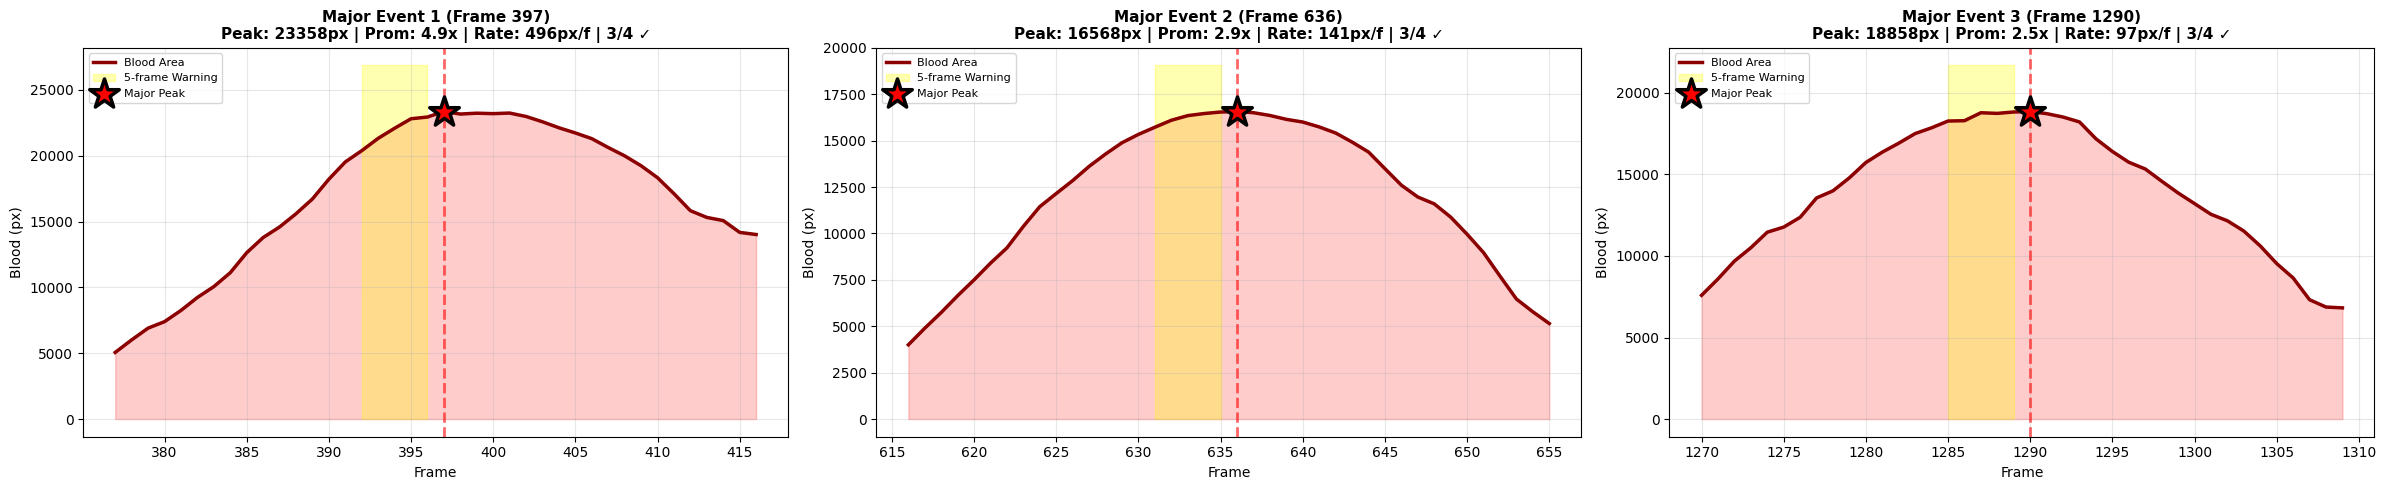

✅ All 3 major peaks visualized

Creating statistics summary...


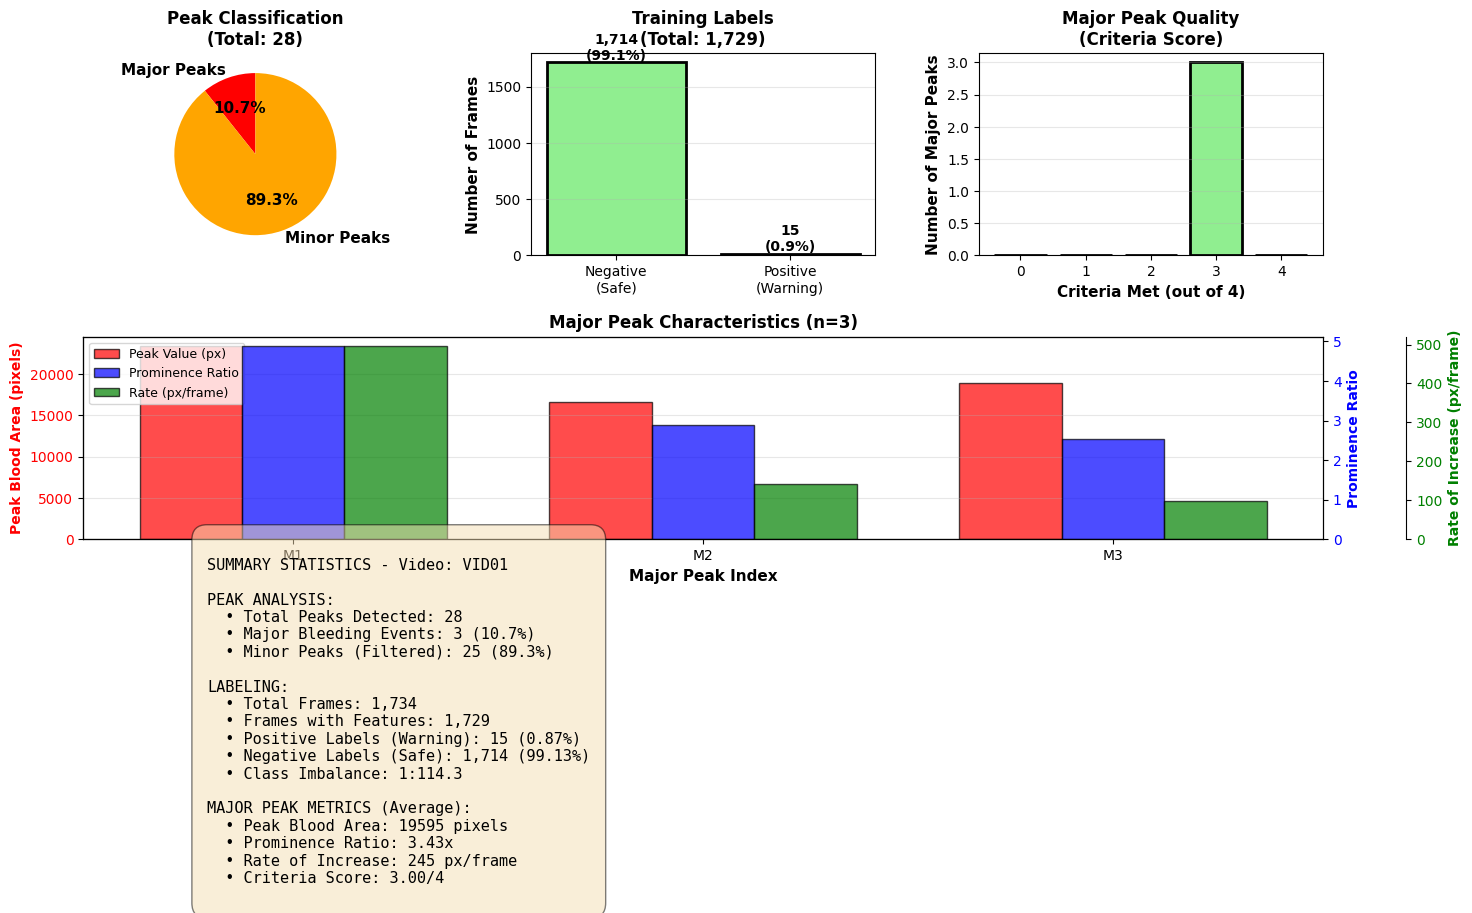

✅ Statistics summary saved

VISUALIZATION COMPLETE
Created 3 comprehensive visualizations:
  1. Full video timeline (blood, labels, instruments)
  2. Detailed view of all 3 major peaks
  3. Statistics summary panel

All saved to: bleeding_prediction_model/


In [16]:
# Cell 9: Visualize Labeling Strategy - FULL VIDEO VIEW
print("\nVisualizing labeling strategy over ENTIRE video...\n")

# ============================================================================
# VISUALIZATION 1: Complete Video Timeline with All Annotations
# ============================================================================
print("Creating comprehensive full-video visualization...")

if len(sample_data['peaks']) > 0:
    fig, axes = plt.subplots(3, 1, figsize=(24, 14))
    
    blood_areas = sample_data['smoothed_blood_areas']
    raw_blood_areas = sample_data['blood_areas']
    frame_indices = sample_data['frame_indices']
    instrument_labels = sample_data['instrument_labels']
    instrument_names = sample_data['instrument_names']
    
    # Separate major and minor peaks
    minor_peaks = [p for p in all_peaks if p not in major_peaks]
    
    # ========================================================================
    # SUBPLOT 1: Blood Area with Peak Classification
    # ========================================================================
    ax1 = axes[0]
    
    # Plot raw and smoothed blood area
    ax1.plot(frame_indices, raw_blood_areas, color='lightcoral', 
            linewidth=0.5, alpha=0.3, label='Raw Blood Area')
    ax1.plot(frame_indices, blood_areas, color='darkred', linewidth=2, 
            label='Smoothed Blood Area', alpha=0.8)
    ax1.fill_between(frame_indices, 0, blood_areas, alpha=0.15, color='red')
    
    # Mark minor peaks (filtered out)
    if len(minor_peaks) > 0:
        ax1.scatter(frame_indices[minor_peaks], blood_areas[minor_peaks],
                  color='orange', s=100, marker='o', alpha=0.7,
                  edgecolors='black', linewidths=1,
                  label=f'Minor Peaks (Filtered) - {len(minor_peaks)}', zorder=3)
    
    # Mark MAJOR peaks
    if len(major_peaks) > 0:
        ax1.scatter(frame_indices[major_peaks], blood_areas[major_peaks],
                  color='red', s=400, marker='*', 
                  edgecolors='black', linewidths=2,
                  label=f'MAJOR Bleeding - {len(major_peaks)}', zorder=5)
        
        # Add peak numbers
        for i, peak in enumerate(major_peaks):
            ax1.text(frame_indices[peak], blood_areas[peak] + blood_areas.max() * 0.05,
                   f'M{i+1}', fontsize=9, ha='center', fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.7, edgecolor='black'))
    
    # Highlight warning zones (5 frames before each major peak)
    for peak in major_peaks:
        warning_start = max(0, peak - Config.PREDICTION_HORIZON)
        warning_end = peak
        warning_frames = frame_indices[warning_start:warning_end]
        ax1.fill_between(warning_frames, 0, blood_areas.max() * 1.15,
                       alpha=0.2, color='yellow', zorder=1)
        # Add vertical line at start of warning
        ax1.axvline(frame_indices[warning_start], color='gold', 
                   linestyle=':', alpha=0.5, linewidth=1.5)
    
    ax1.set_ylabel('Blood Area (pixels)', fontsize=13, fontweight='bold')
    ax1.set_title(f'Full Video Analysis: {list(all_data.keys())[0]}\n'
                 f'Total Peaks: {len(all_peaks)} | Major: {len(major_peaks)} | Minor: {len(minor_peaks)} | '
                 f'Filter Rate: {100*(len(minor_peaks)/len(all_peaks)):.1f}%',
                 fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right', fontsize=10, ncol=2)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([frame_indices[0], frame_indices[-1]])
    
    # ========================================================================
    # SUBPLOT 2: Label Distribution (What Model Sees)
    # ========================================================================
    ax2 = axes[1]
    
    # Create label array for ALL frames in video
    all_video_labels = np.zeros(len(frame_indices))
    for i, frame in enumerate(frame_indices):
        if frame in test_indices:
            idx = np.where(test_indices == frame)[0][0]
            all_video_labels[i] = test_labels[idx]
    
    # Plot as binary heatmap
    ax2.fill_between(frame_indices, 0, 1, where=all_video_labels==1, 
                    color='yellow', alpha=0.6, label='POSITIVE (Bleeding Warning)', step='mid')
    ax2.fill_between(frame_indices, 0, 1, where=all_video_labels==0, 
                    color='lightgreen', alpha=0.3, label='NEGATIVE (Safe)', step='mid')
    
    # Mark major peaks on this plot too
    for peak in major_peaks:
        ax2.axvline(frame_indices[peak], color='red', linestyle='--', 
                   alpha=0.7, linewidth=2)
    
    ax2.set_ylabel('Label', fontsize=13, fontweight='bold')
    ax2.set_yticks([0, 1])
    ax2.set_yticklabels(['Safe\n(0)', 'Warning\n(1)'])
    ax2.set_title(f'Training Labels Over Time (Prediction Horizon: {Config.PREDICTION_HORIZON} frames)\n'
                 f'Positive: {np.sum(all_video_labels):.0f} frames ({100*np.mean(all_video_labels):.2f}%) | '
                 f'Negative: {np.sum(all_video_labels==0):.0f} frames ({100*np.mean(all_video_labels==0):.2f}%)',
                 fontsize=14, fontweight='bold')
    ax2.legend(loc='upper right', fontsize=10)
    ax2.grid(True, alpha=0.3, axis='x')
    ax2.set_xlim([frame_indices[0], frame_indices[-1]])
    
    # ========================================================================
    # SUBPLOT 3: Instrument Usage Timeline
    # ========================================================================
    ax3 = axes[2]
    
    # Create color-coded instrument usage timeline
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']
    
    for i, (inst_name, color) in enumerate(zip(instrument_names, colors)):
        instrument_active = instrument_labels[:, i]
        # Plot as filled regions
        y_pos = i + 0.5
        for frame_idx in range(len(frame_indices)):
            if instrument_active[frame_idx] == 1:
                ax3.fill_between([frame_indices[frame_idx], frame_indices[min(frame_idx+1, len(frame_indices)-1)]], 
                               y_pos - 0.4, y_pos + 0.4, 
                               color=color, alpha=0.7)
    
    # Mark major bleeding events
    for peak in major_peaks:
        ax3.axvline(frame_indices[peak], color='red', linestyle='--', 
                   alpha=0.5, linewidth=2, zorder=10)
    
    ax3.set_ylabel('Instruments', fontsize=13, fontweight='bold')
    ax3.set_xlabel('Frame Index', fontsize=13, fontweight='bold')
    ax3.set_yticks(range(len(instrument_names)))
    ax3.set_yticklabels([f'{i+1}. {name}' for i, name in enumerate(instrument_names)], fontsize=10)
    ax3.set_title('Surgical Instrument Usage Timeline', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='x')
    ax3.set_xlim([frame_indices[0], frame_indices[-1]])
    
    plt.tight_layout()
    plt.savefig(Config.OUTPUT_DIR / '02a_full_video_overview.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Full video overview saved")

# ============================================================================
# VISUALIZATION 2: Zoomed Sections (All Major Peaks)
# ============================================================================
if len(major_peaks) > 0:
    print(f"\nCreating detailed views of all {len(major_peaks)} major bleeding events...")
    
    # Calculate grid layout
    num_peaks = len(major_peaks)
    cols = min(3, num_peaks)
    rows = (num_peaks + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(8*cols, 5*rows))
    if num_peaks == 1:
        axes = np.array([axes])
    axes = axes.flatten() if num_peaks > 1 else axes
    
    for idx, (ax, peak_idx) in enumerate(zip(axes[:num_peaks], major_peaks)):
        # Get window around peak (±20 frames)
        window_start = max(0, peak_idx - 20)
        window_end = min(len(blood_areas), peak_idx + 20)
        
        window_frames = frame_indices[window_start:window_end]
        window_blood = blood_areas[window_start:window_end]
        
        # Determine labels
        window_labels = np.zeros(len(window_frames))
        for i, frame in enumerate(window_frames):
            if frame in test_indices:
                idx_in_test = np.where(test_indices == frame)[0][0]
                window_labels[i] = test_labels[idx_in_test]
        
        # Plot blood area
        ax.plot(window_frames, window_blood, color='darkred', linewidth=2.5, label='Blood Area')
        ax.fill_between(window_frames, 0, window_blood, alpha=0.2, color='red')
        
        # Highlight positive labels
        positive_mask = window_labels == 1
        if np.any(positive_mask):
            ax.fill_between(window_frames, 0, window_blood.max() * 1.15, 
                           where=positive_mask, alpha=0.3, color='yellow',
                           label=f'{Config.PREDICTION_HORIZON}-frame Warning', zorder=1)
        
        # Mark the peak
        peak_pos = np.where(window_frames == frame_indices[peak_idx])[0]
        if len(peak_pos) > 0:
            ax.scatter(frame_indices[peak_idx], window_blood[peak_pos[0]], 
                      color='red', s=500, marker='*', zorder=5,
                      edgecolors='black', linewidths=2.5, label='Major Peak')
            ax.axvline(frame_indices[peak_idx], color='red', linestyle='--', alpha=0.6, linewidth=2)
        
        # Get peak details
        peak_detail_idx = np.where(all_peaks == peak_idx)[0][0]
        details = peak_details[peak_detail_idx]
        
        # Title with metrics
        ax.set_title(f'Major Event {idx+1} (Frame {frame_indices[peak_idx]})\n'
                    f'Peak: {details["peak_value"]:.0f}px | Prom: {details["prominence_ratio"]:.1f}x | '
                    f'Rate: {details["rate_of_increase"]:.0f}px/f | {details["criteria_met"]}/4 ✓',
                    fontsize=11, fontweight='bold')
        
        ax.set_xlabel('Frame', fontsize=10)
        ax.set_ylabel('Blood (px)', fontsize=10)
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(num_peaks, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(Config.OUTPUT_DIR / '02b_all_major_peaks_detailed.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ All {num_peaks} major peaks visualized")

# ============================================================================
# VISUALIZATION 3: Statistics Summary Panel
# ============================================================================
print("\nCreating statistics summary...")

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# Panel 1: Peak Classification Breakdown
ax1 = fig.add_subplot(gs[0, 0])
labels_pie = ['Major Peaks', 'Minor Peaks']
sizes_pie = [len(major_peaks), len(minor_peaks)]
colors_pie = ['red', 'orange']
wedges, texts, autotexts = ax1.pie(sizes_pie, labels=labels_pie, colors=colors_pie, 
                                    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax1.set_title(f'Peak Classification\n(Total: {len(all_peaks)})', fontsize=12, fontweight='bold')

# Panel 2: Label Distribution
ax2 = fig.add_subplot(gs[0, 1])
label_counts = [np.sum(test_labels == 0), np.sum(test_labels == 1)]
label_names = ['Negative\n(Safe)', 'Positive\n(Warning)']
colors_label = ['lightgreen', 'yellow']
bars = ax2.bar(label_names, label_counts, color=colors_label, edgecolor='black', linewidth=2)
ax2.set_ylabel('Number of Frames', fontsize=11, fontweight='bold')
ax2.set_title(f'Training Labels\n(Total: {len(test_labels):,})', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for bar, count in zip(bars, label_counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{count:,}\n({100*count/len(test_labels):.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Panel 3: Criteria Distribution for Major Peaks
ax3 = fig.add_subplot(gs[0, 2])
if len(major_peaks) > 0:
    major_peak_details = [peak_details[np.where(all_peaks == p)[0][0]] for p in major_peaks]
    criteria_counts = [sum([d['criteria_met'] == i for d in major_peak_details]) for i in range(5)]
    ax3.bar([0, 1, 2, 3, 4], criteria_counts, color=['gray', 'orange', 'yellow', 'lightgreen', 'green'],
           edgecolor='black', linewidth=2)
    ax3.set_xlabel('Criteria Met (out of 4)', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Number of Major Peaks', fontsize=11, fontweight='bold')
    ax3.set_title('Major Peak Quality\n(Criteria Score)', fontsize=12, fontweight='bold')
    ax3.set_xticks([0, 1, 2, 3, 4])
    ax3.grid(True, alpha=0.3, axis='y')

# Panel 4: Peak metrics distribution
ax4 = fig.add_subplot(gs[1, :])
if len(major_peaks) > 0:
    major_peak_details = [peak_details[np.where(all_peaks == p)[0][0]] for p in major_peaks]
    peak_values = [d['peak_value'] for d in major_peak_details]
    prominence_ratios = [d['prominence_ratio'] for d in major_peak_details]
    rates = [d['rate_of_increase'] for d in major_peak_details]
    
    x_pos = np.arange(len(major_peaks))
    width = 0.25
    
    ax4_twin1 = ax4.twinx()
    ax4_twin2 = ax4.twinx()
    ax4_twin2.spines['right'].set_position(('outward', 60))
    
    p1 = ax4.bar(x_pos - width, peak_values, width, label='Peak Value (px)', color='red', alpha=0.7, edgecolor='black')
    p2 = ax4_twin1.bar(x_pos, prominence_ratios, width, label='Prominence Ratio', color='blue', alpha=0.7, edgecolor='black')
    p3 = ax4_twin2.bar(x_pos + width, rates, width, label='Rate (px/frame)', color='green', alpha=0.7, edgecolor='black')
    
    ax4.set_xlabel('Major Peak Index', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Peak Blood Area (pixels)', fontsize=10, fontweight='bold', color='red')
    ax4_twin1.set_ylabel('Prominence Ratio', fontsize=10, fontweight='bold', color='blue')
    ax4_twin2.set_ylabel('Rate of Increase (px/frame)', fontsize=10, fontweight='bold', color='green')
    
    ax4.set_title(f'Major Peak Characteristics (n={len(major_peaks)})', fontsize=12, fontweight='bold')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels([f'M{i+1}' for i in range(len(major_peaks))])
    ax4.tick_params(axis='y', labelcolor='red')
    ax4_twin1.tick_params(axis='y', labelcolor='blue')
    ax4_twin2.tick_params(axis='y', labelcolor='green')
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Add legend
    lines = [p1, p2, p3]
    labels = [l.get_label() for l in lines]
    ax4.legend(lines, labels, loc='upper left', fontsize=9)

# Panel 5: Summary statistics text
ax5 = fig.add_subplot(gs[2, :])
ax5.axis('off')

summary_text = f"""
SUMMARY STATISTICS - Video: {list(all_data.keys())[0]}

PEAK ANALYSIS:
  • Total Peaks Detected: {len(all_peaks)}
  • Major Bleeding Events: {len(major_peaks)} ({100*len(major_peaks)/len(all_peaks):.1f}%)
  • Minor Peaks (Filtered): {len(minor_peaks)} ({100*len(minor_peaks)/len(all_peaks):.1f}%)

LABELING:
  • Total Frames: {len(frame_indices):,}
  • Frames with Features: {len(test_indices):,}
  • Positive Labels (Warning): {np.sum(test_labels):,} ({100*np.mean(test_labels):.2f}%)
  • Negative Labels (Safe): {np.sum(test_labels==0):,} ({100*np.mean(test_labels==0):.2f}%)
  • Class Imbalance: 1:{np.sum(test_labels==0)/max(np.sum(test_labels), 1):.1f}

MAJOR PEAK METRICS (Average):
  • Peak Blood Area: {np.mean([peak_details[np.where(all_peaks == p)[0][0]]['peak_value'] for p in major_peaks]):.0f} pixels
  • Prominence Ratio: {np.mean([peak_details[np.where(all_peaks == p)[0][0]]['prominence_ratio'] for p in major_peaks]):.2f}x
  • Rate of Increase: {np.mean([peak_details[np.where(all_peaks == p)[0][0]]['rate_of_increase'] for p in major_peaks]):.0f} px/frame
  • Criteria Score: {np.mean([peak_details[np.where(all_peaks == p)[0][0]]['criteria_met'] for p in major_peaks]):.2f}/4
"""

ax5.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
        verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5, pad=1))

plt.savefig(Config.OUTPUT_DIR / '02c_statistics_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Statistics summary saved")

print("\n" + "="*80)
print("VISUALIZATION COMPLETE")
print("="*80)
print(f"Created 3 comprehensive visualizations:")
print(f"  1. Full video timeline (blood, labels, instruments)")
print(f"  2. Detailed view of all {len(major_peaks)} major peaks")
print(f"  3. Statistics summary panel")
print(f"\nAll saved to: {Config.OUTPUT_DIR}/")

In [ ]:
# Cell 10: Create Complete Dataset
print("\n" + "=" * 80)
print("CREATING COMPLETE DATASET FROM ALL VIDEOS")
print("=" * 80)
print()

all_features = []
all_labels = []
all_video_ids = []

for video_id in tqdm(sorted(all_data.keys()), desc="Processing videos"):
    video_data = all_data[video_id]
    
    # Create temporal features
    features, valid_indices = create_temporal_features(
        video_data,
        window_size=Config.WINDOW_SIZE,
        include_temporal_changes=True
    )
    
    # Create labels
    labels = create_labels(
        valid_indices,
        video_data['peaks'],
        prediction_horizon=Config.PREDICTION_HORIZON
    )
    
    # Store
    all_features.append(features)
    all_labels.append(labels)
    all_video_ids.extend([video_id] * len(labels))
    
    print(f"    {video_id}: {len(features):,} samples, {np.sum(labels)} positive ({100*np.mean(labels):.1f}%)")

# Concatenate all
X = np.vstack(all_features)
y = np.concatenate(all_labels)
video_ids = np.array(all_video_ids)

print(f"\n" + "=" * 80)
print(f"COMPLETE DATASET CREATED")
print("=" * 80)
print(f"\n📊 Dataset Statistics:")
print(f"  Total samples: {len(X):,}")
print(f"  Feature dimensions: {X.shape[1]}")
print(f"  Positive samples: {np.sum(y):,} ({100*np.mean(y):.2f}%)")
print(f"  Negative samples: {np.sum(y==0):,} ({100*np.mean(y==0):.2f}%)")
print(f"  Class imbalance ratio: 1:{np.sum(y==0) / max(np.sum(y), 1):.1f}")
print(f"  Videos: {len(all_data)}")

---
# ✂️ SECTION 5: Train/Validation/Test Split
---

## Split Strategy: Video-Level

We split at the **video level** (not random frames) to prevent data leakage:

### Why Video-Level Split?

1. **Prevent Leakage**: Consecutive frames are very similar
2. **Realistic Evaluation**: Test on completely unseen surgeries
3. **Better Generalization**: Model learns patterns, not memorizes videos

### Split Ratios:

- **Train**: 70% of videos
- **Validation**: 15% of videos  
- **Test**: 15% of videos

### Example:

```
35 total videos:
├── Train: 24 videos (~70%)
├── Val: 6 videos (~15%)
└── Test: 5 videos (~15%)
```

In [ ]:
# Cell 11: Video-Level Train/Val/Test Split
print("\n" + "=" * 80)
print("TRAIN/VALIDATION/TEST SPLIT (VIDEO-LEVEL)")
print("=" * 80)
print()

# Get unique videos
unique_videos = np.unique(video_ids)
print(f"Total videos: {len(unique_videos)}")

# Split videos (not frames)
train_videos, test_videos = train_test_split(
    unique_videos, 
    test_size=Config.TEST_SIZE, 
    random_state=42
)

train_videos, val_videos = train_test_split(
    train_videos,
    test_size=Config.VAL_SIZE / (1 - Config.TEST_SIZE),
    random_state=42
)

# Create masks for frames
train_mask = np.isin(video_ids, train_videos)
val_mask = np.isin(video_ids, val_videos)
test_mask = np.isin(video_ids, test_videos)

# Split data
X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"\n📊 Split Results:")
print(f"\nTrain:")
print(f"  Videos: {len(train_videos)} ({100*len(train_videos)/len(unique_videos):.1f}%)")
print(f"  Samples: {len(X_train):,}")
print(f"  Positive: {np.sum(y_train):,} ({100*np.mean(y_train):.2f}%)")
print(f"  Videos: {sorted(train_videos)[:5]}...")

print(f"\nValidation:")
print(f"  Videos: {len(val_videos)} ({100*len(val_videos)/len(unique_videos):.1f}%)")
print(f"  Samples: {len(X_val):,}")
print(f"  Positive: {np.sum(y_val):,} ({100*np.mean(y_val):.2f}%)")
print(f"  Videos: {sorted(val_videos)}")

print(f"\nTest:")
print(f"  Videos: {len(test_videos)} ({100*len(test_videos)/len(unique_videos):.1f}%)")
print(f"  Samples: {len(X_test):,}")
print(f"  Positive: {np.sum(y_test):,} ({100*np.mean(y_test):.2f}%)")
print(f"  Videos: {sorted(test_videos)}")

# Save split info
split_info = {
    'train_videos': train_videos.tolist(),
    'val_videos': val_videos.tolist(),
    'test_videos': test_videos.tolist(),
}

with open(Config.OUTPUT_DIR / 'split_info.json', 'w') as f:
    json.dump(split_info, f, indent=2)

print(f"\n✅ Split information saved: {Config.OUTPUT_DIR / 'split_info.json'}")

In [ ]:
# Cell 12: Feature Scaling
print("\n" + "=" * 80)
print("FEATURE SCALING")
print("=" * 80)
print()

# Fit scaler on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Feature scaling statistics (from training set):")
print(f"  Mean: {scaler.mean_[:5]} ... (showing first 5)")
print(f"  Std: {scaler.scale_[:5]} ... (showing first 5)")

print(f"\nScaled data ranges:")
print(f"  Train: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]")
print(f"  Val: [{X_val_scaled.min():.2f}, {X_val_scaled.max():.2f}]")
print(f"  Test: [{X_test_scaled.min():.2f}, {X_test_scaled.max():.2f}]")

# Save scaler
import pickle
with open(Config.OUTPUT_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f"\n✅ Scaler saved: {Config.OUTPUT_DIR / 'scaler.pkl'}")

---
# 🏗️ SECTION 6: Model Architecture
---

## MLP Architecture

```
Input Layer: 57 features
    ↓
Dense(256) + BatchNorm + ReLU + Dropout(0.4)
    ↓
Dense(128) + BatchNorm + ReLU + Dropout(0.3)
    ↓
Dense(64) + BatchNorm + ReLU + Dropout(0.2)
    ↓
Dense(32) + ReLU + Dropout(0.1)
    ↓
Dense(2) → Softmax → [P(no bleeding), P(bleeding)]
```

### Why This Architecture?

1. **Deep but not too deep**: 4 hidden layers capture complex patterns without overfitting
2. **Decreasing dimensions**: 256→128→64→32 progressively compresses information
3. **BatchNorm**: Stabilizes training, allows higher learning rates
4. **Dropout**: Prevents overfitting (higher dropout in earlier layers)
5. **ReLU activation**: Non-linearity, works well for medical data

### Total Parameters:

```
Layer 1: 57 × 256 = 14,592 params
Layer 2: 256 × 128 = 32,768 params
Layer 3: 128 × 64 = 8,192 params
Layer 4: 64 × 32 = 2,048 params
Output: 32 × 2 = 64 params
Total: ~57,664 trainable parameters
```

In [ ]:
# Cell 13: Define MLP Model
class BleedingPredictionMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout_rates):
        super(BleedingPredictionMLP, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        # Hidden layers
        for i, (hidden_dim, dropout) in enumerate(zip(hidden_dims, dropout_rates)):
            # Linear layer
            layers.append(nn.Linear(prev_dim, hidden_dim))
            # Batch normalization
            layers.append(nn.BatchNorm1d(hidden_dim))
            # Activation
            layers.append(nn.ReLU())
            # Dropout
            layers.append(nn.Dropout(dropout))
            
            prev_dim = hidden_dim
        
        # Output layer
        layers.append(nn.Linear(prev_dim, 2))  # 2 classes
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

# Create model
input_dim = X_train_scaled.shape[1]
model = BleedingPredictionMLP(
    input_dim=input_dim,
    hidden_dims=Config.HIDDEN_DIMS,
    dropout_rates=Config.DROPOUT_RATES
).to(Config.DEVICE)

print("\n" + "=" * 80)
print("MODEL ARCHITECTURE")
print("=" * 80)
print()
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n📊 Model Statistics:")
print(f"  Input dimension: {input_dim}")
print(f"  Hidden layers: {len(Config.HIDDEN_DIMS)}")
print(f"  Hidden dimensions: {Config.HIDDEN_DIMS}")
print(f"  Output dimension: 2 (binary classification)")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Device: {Config.DEVICE}")

**Continue in next cell...**